# Analisis de Quarterbacks (QB_DATA)

**Descripcion:** Analisis exploratorio completo de la tabla QB_DATA que contiene estadisticas de quarterbacks de la NFL.

**Contenido:**
1. Configuracion e importaciones
2. Conexion a base de datos
3. Carga de datos
4. Analisis exploratorio
5. Analisis temporal
6. Analisis de rendimiento
7. Visualizaciones
8. Deteccion de problemas
9. Exportacion de resultados
10. Conclusiones

---
## 1. Configuracion e Importaciones

In [1]:
# Importaciones principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
from datetime import datetime
import warnings

# Configuracion de visualizacion
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Estilo de graficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Librerias cargadas exitosamente")
print(f"Fecha de analisis: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Librerias cargadas exitosamente
Fecha de analisis: 2026-01-27 18:26:10


In [5]:
# Conectar a la base de datos
load_dotenv()

DB_NAME = os.getenv("DB_NAME")
DB_HOST = os.getenv("DB_HOST")
DB_PASS = os.getenv("DB_PASS")
DB_PORT = os.getenv("DB_PORT", "5433")
DB_USER = os.getenv("DB_USER")

engine = create_engine(
    f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    connect_args={'connect_timeout': 10}
)

# Verificar conexion
with engine.connect() as conn:
    result = conn.execute(text("SELECT 1"))
    print("Conexion exitosa a la base de datos")

# Cargar datos de QB
query = "SELECT * FROM qb_data ORDER BY season DESC, week DESC, p_name"
with engine.connect() as conn:
    df_qb = pd.read_sql(text(query), conn)

print(f"Total de registros: {len(df_qb):,}")
print(f"Columnas: {df_qb.columns.tolist()}")

Conexion exitosa a la base de datos
Total de registros: 1,244
Columnas: ['season', 'week', 'p_name', 'team', 'attempts', 'completions', 'pass_yards', 'pass_touchdowns', 'interceptions', 'passer_rating', 'completion_percentage', 'rushing_rushyds', 'rushing_carries', 'rushing_longrush', 'rushing_rushtd', 'g_location', 'team_against', 'total_yards', 'passing_yards', 'rushing_yards', 'turnovers', 'sacks', 'points_allowed', 'player_gsis_id']


In [6]:
# Ver estructura de datos y estadísticas básicas
print("Primeras filas:")
print(df_qb.head())
print("\n" + "="*80)
print("\nEstadísticas descriptivas:")
print(df_qb.describe())

Primeras filas:
   season  week          p_name team  attempts  completions  pass_yards  \
0    2025     5  Baker Mayfield   TB        33           29         379   
1    2025     5          Bo Nix  DEN        39           24         242   
2    2025     5     Bryce Young  CAR        30           19         198   
3    2025     5        Cam Ward  TEN        39           21         265   
4    2025     5    Carson Wentz  MIN        34           25         236   

   pass_touchdowns  interceptions  passer_rating  completion_percentage  \
0                2              0         134.72                  87.88   
1                1              0          87.77                  61.54   
2                2              1          90.69                  63.33   
3                0              1          64.58                  53.85   
4                1              0         102.08                  73.53   

   rushing_rushyds  rushing_carries  rushing_longrush  rushing_rushtd  \
0        

In [7]:
# Ver la distribución de temporadas y semanas disponibles
print("Distribución por temporada:")
print(df_qb['season'].value_counts().sort_index())
print("\nDistribución por semana:")
print(df_qb['week'].value_counts().sort_index())
print("\nValores nulos por columna:")
print(df_qb.isnull().sum())

Distribución por temporada:
2023    544
2024    545
2025    155
Name: season, dtype: int64

Distribución por semana:
1     96
2     94
3     97
4     96
5     84
6     56
7     54
8     64
9     60
10    57
11    56
12    58
13    58
14    58
15    64
16    66
17    64
18    62
Name: week, dtype: int64

Valores nulos por columna:
season                     0
week                       0
p_name                     0
team                       0
attempts                   0
completions                0
pass_yards                 0
pass_touchdowns            0
interceptions              0
passer_rating              0
completion_percentage      0
rushing_rushyds          741
rushing_carries          741
rushing_longrush         741
rushing_rushtd           741
g_location                 0
team_against               0
total_yards                0
passing_yards              0
rushing_yards              0
turnovers                  0
sacks                      0
points_allowed             0
p

In [8]:
# Ver cuántos QBs únicos hay y su distribución de juegos
qb_counts = df_qb.groupby('player_gsis_id').agg({
    'p_name': 'first',
    'season': 'count'
}).rename(columns={'season': 'juegos'}).sort_values('juegos', ascending=False)

print(f"Total de QBs únicos: {len(qb_counts)}")
print("\nTop 20 QBs por cantidad de juegos:")
print(qb_counts.head(20))

Total de QBs únicos: 86

Top 20 QBs por cantidad de juegos:
                          p_name  juegos
player_gsis_id                          
00-0033106            Jared Goff      39
00-0034855        Baker Mayfield      39
00-0034857            Josh Allen      38
00-0034796         Lamar Jackson      37
00-0030565            Geno Smith      37
00-0033873       Patrick Mahomes      37
00-0039163           C.J. Stroud      36
00-0026498      Matthew Stafford      36
00-0036389           Jalen Hurts      35
00-0036355        Justin Herbert      35
00-0036264           Jordan Love      35
00-0036212        Tua Tagovailoa      33
00-0037834           Brock Purdy      33
00-0039150           Bryce Young      33
00-0033077          Dak Prescott      30
00-0036971       Trevor Lawrence      30
00-0035228          Kyler Murray      30
00-0029263        Russell Wilson      29
00-0036442            Joe Burrow      28
00-0031280            Derek Carr      27


In [9]:
# Analizar correlaciones entre variables para entender qué predice qué
variables_objetivo = ['pass_yards', 'completions', 'attempts', 'pass_touchdowns', 'interceptions', 'passer_rating']
variables_contexto = ['total_yards', 'passing_yards', 'rushing_yards', 'turnovers', 'sacks', 'points_allowed']

# Correlaciones
corr_matrix = df_qb[variables_objetivo + variables_contexto].corr()
print("Correlaciones de variables objetivo:")
print(corr_matrix[variables_objetivo].round(2))

Correlaciones de variables objetivo:
                 pass_yards  completions  attempts  pass_touchdowns  \
pass_yards             1.00         0.76      0.64             0.51   
completions            0.76         1.00      0.86             0.34   
attempts               0.64         0.86      1.00             0.18   
pass_touchdowns        0.51         0.34      0.18             1.00   
interceptions          0.03         0.09      0.21            -0.10   
passer_rating          0.48         0.24     -0.11             0.71   
total_yards            0.75         0.47      0.32             0.48   
passing_yards          0.94         0.68      0.55             0.51   
rushing_yards         -0.09        -0.20     -0.27             0.07   
turnovers             -0.02         0.06      0.14            -0.13   
sacks                  0.02        -0.06     -0.08             0.06   
points_allowed         0.11         0.12      0.19             0.08   

                 interceptions  passer_

In [10]:
# SISTEMA DE PREDICCIÓN DE QB - INGENIERÍA DE FEATURES
# =====================================================

def crear_features_historicas(df, jugador_col='player_gsis_id', ventanas=[3, 5]):
    """
    Crea features basadas en el rendimiento histórico del QB.
    Usa ventanas móviles para capturar tendencias recientes.
    """
    df = df.sort_values(['player_gsis_id', 'season', 'week']).copy()
    
    # Variables a promediar
    vars_promedio = ['pass_yards', 'completions', 'attempts', 'pass_touchdowns', 
                     'interceptions', 'passer_rating', 'completion_percentage',
                     'sacks', 'total_yards', 'passing_yards']
    
    for var in vars_promedio:
        for ventana in ventanas:
            # Promedio móvil (excluyendo el juego actual - shift 1)
            col_name = f'{var}_avg_{ventana}'
            df[col_name] = df.groupby(jugador_col)[var].transform(
                lambda x: x.shift(1).rolling(window=ventana, min_periods=1).mean()
            )
            
            # Desviación estándar móvil para capturar consistencia
            col_std = f'{var}_std_{ventana}'
            df[col_name] = df.groupby(jugador_col)[var].transform(
                lambda x: x.shift(1).rolling(window=ventana, min_periods=2).std()
            )
    
    # Tendencia (diferencia entre últimos 3 vs últimos 5 juegos)
    for var in ['pass_yards', 'passer_rating', 'completions']:
        df[f'{var}_trend'] = df.groupby(jugador_col)[var].transform(
            lambda x: x.shift(1).rolling(3, min_periods=1).mean() - x.shift(1).rolling(5, min_periods=2).mean()
        )
    
    # Juegos acumulados del QB (experiencia)
    df['juegos_acumulados'] = df.groupby(jugador_col).cumcount()
    
    # Promedio de carrera del QB
    for var in ['pass_yards', 'passer_rating', 'pass_touchdowns', 'interceptions']:
        df[f'{var}_carrera_avg'] = df.groupby(jugador_col)[var].transform(
            lambda x: x.shift(1).expanding().mean()
        )
    
    return df

# Aplicar ingeniería de features
print("Creando features históricas...")
df_features = crear_features_historicas(df_qb)
print(f"Nuevas columnas creadas: {len(df_features.columns) - len(df_qb.columns)}")
print(f"Total columnas: {len(df_features.columns)}")

Creando features históricas...
Nuevas columnas creadas: 28
Total columnas: 52


In [11]:
# Agregar features del rival (puntos permitidos promedio del equipo contrario)
# Esto nos ayuda a saber qué tan fuerte es la defensa rival

def crear_features_rival(df):
    """
    Crea features basadas en la defensa del equipo rival.
    """
    df = df.copy()
    
    # Calcular estadísticas promedio permitidas por cada defensa
    # Agrupamos por equipo rival para ver cuántas yardas/puntos permite en promedio
    stats_defensa = df.groupby(['season', 'team_against']).agg({
        'pass_yards': 'mean',
        'pass_touchdowns': 'mean',
        'interceptions': 'mean',
        'passer_rating': 'mean',
        'total_yards': 'mean',
        'points_allowed': 'mean'
    }).reset_index()
    
    stats_defensa.columns = ['season', 'team_against', 
                             'def_pass_yards_allowed', 'def_pass_td_allowed',
                             'def_int_forced', 'def_passer_rating_allowed',
                             'def_total_yards_allowed', 'def_points_scored']
    
    # Merge con datos originales
    df = df.merge(stats_defensa, on=['season', 'team_against'], how='left')
    
    # Home/Away encoding
    df['is_home'] = (df['g_location'] == 'Home').astype(int)
    
    return df

df_features = crear_features_rival(df_features)
print("Features del rival agregadas")
print(f"Total columnas: {len(df_features.columns)}")

Features del rival agregadas
Total columnas: 59


In [12]:
# Preparar datos para modelado
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# Variables objetivo a predecir
TARGETS = ['pass_yards', 'completions', 'attempts', 'pass_touchdowns', 'passer_rating']

# Features a usar (excluir variables que serían "leakage" o del mismo juego)
exclude_cols = ['season', 'week', 'p_name', 'team', 'player_gsis_id', 'g_location', 'team_against',
                'pass_yards', 'completions', 'attempts', 'pass_touchdowns', 'interceptions', 
                'passer_rating', 'completion_percentage', 'rushing_rushyds', 'rushing_carries',
                'rushing_longrush', 'rushing_rushtd', 'total_yards', 'passing_yards', 
                'rushing_yards', 'turnovers', 'sacks', 'points_allowed']

# Seleccionar features
feature_cols = [col for col in df_features.columns if col not in exclude_cols]
print(f"Features seleccionadas ({len(feature_cols)}):")
print(feature_cols)

Features seleccionadas (35):
['pass_yards_avg_3', 'pass_yards_avg_5', 'completions_avg_3', 'completions_avg_5', 'attempts_avg_3', 'attempts_avg_5', 'pass_touchdowns_avg_3', 'pass_touchdowns_avg_5', 'interceptions_avg_3', 'interceptions_avg_5', 'passer_rating_avg_3', 'passer_rating_avg_5', 'completion_percentage_avg_3', 'completion_percentage_avg_5', 'sacks_avg_3', 'sacks_avg_5', 'total_yards_avg_3', 'total_yards_avg_5', 'passing_yards_avg_3', 'passing_yards_avg_5', 'pass_yards_trend', 'passer_rating_trend', 'completions_trend', 'juegos_acumulados', 'pass_yards_carrera_avg', 'passer_rating_carrera_avg', 'pass_touchdowns_carrera_avg', 'interceptions_carrera_avg', 'def_pass_yards_allowed', 'def_pass_td_allowed', 'def_int_forced', 'def_passer_rating_allowed', 'def_total_yards_allowed', 'def_points_scored', 'is_home']


In [13]:
# Preparar dataset limpio para entrenamiento
# Eliminar filas donde hay muchos NaN en features (primeros juegos de cada QB)

df_model = df_features.copy()

# Ver cuántos NaN hay por fila en las features
nan_por_fila = df_model[feature_cols].isnull().sum(axis=1)
print(f"Distribución de NaN por fila:")
print(nan_por_fila.value_counts().sort_index())

# Mantener solo filas con menos de 5 NaN
df_model = df_model[nan_por_fila < 5].copy()
print(f"\nRegistros después de filtrar: {len(df_model)}")

# Rellenar NaN restantes con la mediana de cada columna
for col in feature_cols:
    if df_model[col].isnull().any():
        df_model[col].fillna(df_model[col].median(), inplace=True)

print(f"NaN restantes: {df_model[feature_cols].isnull().sum().sum()}")

Distribución de NaN por fila:
0     1085
23      73
27      86
dtype: int64

Registros después de filtrar: 1085
NaN restantes: 0


In [14]:
# Dividir datos en entrenamiento (2023-2024) y prueba (2025)
train_data = df_model[df_model['season'] < 2025].copy()
test_data = df_model[df_model['season'] == 2025].copy()

print(f"Datos de entrenamiento: {len(train_data)} registros (2023-2024)")
print(f"Datos de prueba: {len(test_data)} registros (2025)")

X_train = train_data[feature_cols]
X_test = test_data[feature_cols]

# Escalar features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nShape entrenamiento: {X_train_scaled.shape}")
print(f"Shape prueba: {X_test_scaled.shape}")

Datos de entrenamiento: 938 registros (2023-2024)
Datos de prueba: 147 registros (2025)

Shape entrenamiento: (938, 35)
Shape prueba: (147, 35)


In [15]:
# Función para evaluar múltiples modelos
def evaluar_modelos(X_train, y_train, X_test, y_test, target_name):
    """
    Evalúa múltiples modelos y retorna el mejor.
    """
    modelos = {
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.1),
        'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
        'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
        'XGBoost': xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
    }
    
    resultados = []
    
    for nombre, modelo in modelos.items():
        # Entrenar
        modelo.fit(X_train, y_train)
        
        # Predecir
        y_pred_train = modelo.predict(X_train)
        y_pred_test = modelo.predict(X_test)
        
        # Métricas
        resultado = {
            'Modelo': nombre,
            'R2_Train': r2_score(y_train, y_pred_train),
            'R2_Test': r2_score(y_test, y_pred_test),
            'MAE_Test': mean_absolute_error(y_test, y_pred_test),
            'RMSE_Test': np.sqrt(mean_squared_error(y_test, y_pred_test))
        }
        resultados.append(resultado)
    
    df_resultados = pd.DataFrame(resultados).sort_values('R2_Test', ascending=False)
    return df_resultados, modelos

# Evaluar modelos para pass_yards
print("="*60)
print("EVALUACIÓN DE MODELOS PARA: PASS_YARDS (Yardas de Pase)")
print("="*60)

y_train = train_data['pass_yards']
y_test = test_data['pass_yards']

resultados_pass_yards, modelos_pass_yards = evaluar_modelos(
    X_train_scaled, y_train, X_test_scaled, y_test, 'pass_yards'
)
print(resultados_pass_yards.to_string(index=False))

EVALUACIÓN DE MODELOS PARA: PASS_YARDS (Yardas de Pase)
          Modelo  R2_Train  R2_Test  MAE_Test  RMSE_Test
      ElasticNet      0.16     0.17     49.30      61.40
           Lasso      0.16     0.16     49.82      61.75
           Ridge      0.16     0.14     50.23      62.24
    RandomForest      0.78     0.13     50.18      62.72
GradientBoosting      0.91     0.04     51.85      66.04
         XGBoost      0.89     0.03     54.58      66.32


In [16]:
# Evaluar para COMPLETIONS
print("\n" + "="*60)
print("EVALUACIÓN DE MODELOS PARA: COMPLETIONS (Pases Completados)")
print("="*60)

y_train = train_data['completions']
y_test = test_data['completions']

resultados_completions, _ = evaluar_modelos(
    X_train_scaled, y_train, X_test_scaled, y_test, 'completions'
)
print(resultados_completions.to_string(index=False))

# Evaluar para ATTEMPTS
print("\n" + "="*60)
print("EVALUACIÓN DE MODELOS PARA: ATTEMPTS (Intentos de Pase)")
print("="*60)

y_train = train_data['attempts']
y_test = test_data['attempts']

resultados_attempts, _ = evaluar_modelos(
    X_train_scaled, y_train, X_test_scaled, y_test, 'attempts'
)
print(resultados_attempts.to_string(index=False))


EVALUACIÓN DE MODELOS PARA: COMPLETIONS (Pases Completados)
          Modelo  R2_Train  R2_Test  MAE_Test  RMSE_Test
           Lasso      0.09     0.15      3.91       4.88
      ElasticNet      0.10     0.15      3.92       4.89
           Ridge      0.11     0.12      4.04       4.97
    RandomForest      0.75     0.08      4.06       5.08
         XGBoost      0.92     0.02      4.14       5.24
GradientBoosting      0.92    -0.05      4.30       5.42

EVALUACIÓN DE MODELOS PARA: ATTEMPTS (Intentos de Pase)
          Modelo  R2_Train  R2_Test  MAE_Test  RMSE_Test
           Lasso      0.09     0.16      5.72       7.06
      ElasticNet      0.10     0.15      5.76       7.11
           Ridge      0.11     0.14      5.83       7.14
    RandomForest      0.73     0.04      6.25       7.53
         XGBoost      0.91     0.02      6.24       7.60
GradientBoosting      0.91     0.00      6.33       7.69


In [ ]:
# Evaluar para PASS_TOUCHDOWNS
print("\n" + "="*60)
print("EVALUACIÓN DE MODELOS PARA: PASS_TOUCHDOWNS (Touchdowns)")
print("="*60)

y_train = train_data['pass_touchdowns']
y_test = test_data['pass_touchdowns']

resultados_tds, _ = evaluar_modelos(
    X_train_scaled, y_train, X_test_scaled, y_test, 'pass_touchdowns'
)
print(resultados_tds.to_string(index=False))

# Evaluar para PASSER_RATING
print("\n" + "="*60)
print("EVALUACIÓN DE MODELOS PARA: PASSER_RATING")
print("="*60)

y_train = train_data['passer_rating']
y_test = test_data['passer_rating']

resultados_rating, _ = evaluar_modelos(
    X_train_scaled, y_train, X_test_scaled, y_test, 'passer_rating'
)
print(resultados_rating.to_string(index=False))

In [17]:
# Evaluar para PASS_TOUCHDOWNS
print("="*60)
print("EVALUACIÓN DE MODELOS PARA: PASS_TOUCHDOWNS (Touchdowns)")
print("="*60)

y_train = train_data['pass_touchdowns']
y_test = test_data['pass_touchdowns']

resultados_tds, _ = evaluar_modelos(
    X_train_scaled, y_train, X_test_scaled, y_test, 'pass_touchdowns'
)
print(resultados_tds.to_string(index=False))

# Evaluar para PASSER_RATING
print("\n" + "="*60)
print("EVALUACIÓN DE MODELOS PARA: PASSER_RATING")
print("="*60)

y_train = train_data['passer_rating']
y_test = test_data['passer_rating']

resultados_rating, _ = evaluar_modelos(
    X_train_scaled, y_train, X_test_scaled, y_test, 'passer_rating'
)
print(resultados_rating.to_string(index=False))

EVALUACIÓN DE MODELOS PARA: PASS_TOUCHDOWNS (Touchdowns)
          Modelo  R2_Train  R2_Test  MAE_Test  RMSE_Test
      ElasticNet      0.10     0.21      0.76       0.96
           Ridge      0.13     0.20      0.76       0.97
           Lasso      0.08     0.18      0.78       0.98
    RandomForest      0.76     0.15      0.78       1.00
         XGBoost      0.89     0.09      0.83       1.03
GradientBoosting      0.90     0.01      0.87       1.08

EVALUACIÓN DE MODELOS PARA: PASSER_RATING
          Modelo  R2_Train  R2_Test  MAE_Test  RMSE_Test
      ElasticNet      0.14     0.25     17.99      22.36
           Lasso      0.14     0.25     18.04      22.37
           Ridge      0.14     0.24     18.16      22.51
    RandomForest      0.76     0.13     19.32      24.04
GradientBoosting      0.89     0.12     19.47      24.12
         XGBoost      0.88     0.11     19.51      24.34


In [ ]:
# RESUMEN DE MEJORES MODELOS POR TARGET
print("="*70)
print("RESUMEN: MEJOR MODELO POR CADA ESTADÍSTICA")
print("="*70)

resumen = {
    'Estadística': ['Pass Yards', 'Completions', 'Attempts', 'Pass TDs', 'Passer Rating'],
    'Mejor Modelo': ['ElasticNet', 'Lasso', 'Lasso', 'ElasticNet', 'ElasticNet'],
    'R2 Test': [0.17, 0.15, 0.16, 0.21, 0.25],
    'MAE': [49.3, 3.91, 5.72, 0.76, 17.99],
    'Interpretación MAE': ['±49 yardas', '±4 pases', '±6 intentos', '±0.76 TDs', '±18 puntos rating']
}

df_resumen = pd.DataFrame(resumen)
print(df_resumen.to_string(index=False))

print("\n" + "="*70)
print("CONCLUSIÓN: ElasticNet es el modelo más consistente")
print("="*70)
print("Ahora vamos a MEJORAR ElasticNet con:")
print("1. Mejor ingeniería de features")
print("2. Optimización de hiperparámetros")
print("3. Features de interacción")

In [18]:
# RESUMEN DE MEJORES MODELOS POR TARGET
print("="*70)
print("RESUMEN: MEJOR MODELO POR CADA ESTADÍSTICA")
print("="*70)

resumen = {
    'Estadística': ['Pass Yards', 'Completions', 'Attempts', 'Pass TDs', 'Passer Rating'],
    'Mejor Modelo': ['ElasticNet', 'Lasso', 'Lasso', 'ElasticNet', 'ElasticNet'],
    'R2 Test': [0.17, 0.15, 0.16, 0.21, 0.25],
    'MAE': [49.3, 3.91, 5.72, 0.76, 17.99],
    'Interpretación MAE': ['±49 yardas', '±4 pases', '±6 intentos', '±0.76 TDs', '±18 puntos rating']
}

df_resumen = pd.DataFrame(resumen)
print(df_resumen.to_string(index=False))

print("\n" + "="*70)
print("CONCLUSIÓN: ElasticNet es el modelo más consistente")
print("="*70)

RESUMEN: MEJOR MODELO POR CADA ESTADÍSTICA
  Estadística Mejor Modelo  R2 Test   MAE Interpretación MAE
   Pass Yards   ElasticNet     0.17 49.30         ±49 yardas
  Completions        Lasso     0.15  3.91           ±4 pases
     Attempts        Lasso     0.16  5.72        ±6 intentos
     Pass TDs   ElasticNet     0.21  0.76          ±0.76 TDs
Passer Rating   ElasticNet     0.25 17.99  ±18 puntos rating

CONCLUSIÓN: ElasticNet es el modelo más consistente


In [19]:
# MEJORA 1: INGENIERÍA DE FEATURES AVANZADA
print("="*70)
print("MEJORANDO EL MODELO - FASE 1: Features Avanzadas")
print("="*70)

def crear_features_avanzadas(df):
    """
    Crea features más sofisticadas para mejorar predicciones.
    """
    df = df.sort_values(['player_gsis_id', 'season', 'week']).copy()
    
    # 1. PROMEDIOS PONDERADOS (más peso a juegos recientes)
    def weighted_avg(x, weights=[0.5, 0.3, 0.2]):
        """Promedio ponderado de últimos 3 juegos"""
        x_shifted = x.shift(1)
        result = []
        for i in range(len(x)):
            vals = x_shifted.iloc[max(0,i-2):i+1].values[-3:]
            if len(vals) == 0:
                result.append(np.nan)
            elif len(vals) < 3:
                result.append(np.mean(vals))
            else:
                result.append(np.average(vals, weights=weights[-len(vals):]))
        return pd.Series(result, index=x.index)
    
    for var in ['pass_yards', 'completions', 'passer_rating', 'pass_touchdowns']:
        df[f'{var}_weighted_avg'] = df.groupby('player_gsis_id')[var].transform(weighted_avg)
    
    # 2. MOMENTUM (cambio porcentual reciente)
    for var in ['pass_yards', 'passer_rating']:
        avg_3 = df.groupby('player_gsis_id')[var].transform(
            lambda x: x.shift(1).rolling(3, min_periods=1).mean()
        )
        avg_6 = df.groupby('player_gsis_id')[var].transform(
            lambda x: x.shift(1).rolling(6, min_periods=2).mean()
        )
        df[f'{var}_momentum'] = (avg_3 - avg_6) / (avg_6 + 1)
    
    # 3. CONSISTENCIA (coeficiente de variación)
    for var in ['pass_yards', 'completions']:
        mean_val = df.groupby('player_gsis_id')[var].transform(
            lambda x: x.shift(1).rolling(5, min_periods=2).mean()
        )
        std_val = df.groupby('player_gsis_id')[var].transform(
            lambda x: x.shift(1).rolling(5, min_periods=2).std()
        )
        df[f'{var}_consistency'] = 1 - (std_val / (mean_val + 1))  # Mayor = más consistente
    
    # 4. RENDIMIENTO VS PROMEDIO DE CARRERA
    for var in ['pass_yards', 'passer_rating']:
        carrera_avg = df.groupby('player_gsis_id')[var].transform(
            lambda x: x.shift(1).expanding().mean()
        )
        recent_avg = df.groupby('player_gsis_id')[var].transform(
            lambda x: x.shift(1).rolling(3, min_periods=1).mean()
        )
        df[f'{var}_vs_carrera'] = recent_avg - carrera_avg
    
    # 5. MEJOR/PEOR JUEGO RECIENTE
    for var in ['pass_yards', 'passer_rating']:
        df[f'{var}_max_5'] = df.groupby('player_gsis_id')[var].transform(
            lambda x: x.shift(1).rolling(5, min_periods=1).max()
        )
        df[f'{var}_min_5'] = df.groupby('player_gsis_id')[var].transform(
            lambda x: x.shift(1).rolling(5, min_periods=1).min()
        )
    
    # 6. EFICIENCIA
    df['yards_per_attempt_hist'] = df.groupby('player_gsis_id').apply(
        lambda g: (g['pass_yards'].shift(1).rolling(5, min_periods=1).sum() / 
                   g['attempts'].shift(1).rolling(5, min_periods=1).sum())
    ).reset_index(level=0, drop=True)
    
    df['td_rate_hist'] = df.groupby('player_gsis_id').apply(
        lambda g: (g['pass_touchdowns'].shift(1).rolling(5, min_periods=1).sum() / 
                   g['attempts'].shift(1).rolling(5, min_periods=1).sum())
    ).reset_index(level=0, drop=True)
    
    return df

# Aplicar features avanzadas
df_avanzado = crear_features_avanzadas(df_features)
nuevas_cols = [c for c in df_avanzado.columns if c not in df_features.columns]
print(f"Nuevas features creadas: {len(nuevas_cols)}")
print(nuevas_cols)

MEJORANDO EL MODELO - FASE 1: Features Avanzadas
Nuevas features creadas: 16
['pass_yards_weighted_avg', 'completions_weighted_avg', 'passer_rating_weighted_avg', 'pass_touchdowns_weighted_avg', 'pass_yards_momentum', 'passer_rating_momentum', 'pass_yards_consistency', 'completions_consistency', 'pass_yards_vs_carrera', 'passer_rating_vs_carrera', 'pass_yards_max_5', 'pass_yards_min_5', 'passer_rating_max_5', 'passer_rating_min_5', 'yards_per_attempt_hist', 'td_rate_hist']


In [20]:
# Actualizar lista de features incluyendo las nuevas
feature_cols_v2 = feature_cols + nuevas_cols
print(f"Total features ahora: {len(feature_cols_v2)}")

# Preparar datos con nuevas features
df_model_v2 = df_avanzado.copy()

# Filtrar filas con muchos NaN
nan_por_fila = df_model_v2[feature_cols_v2].isnull().sum(axis=1)
df_model_v2 = df_model_v2[nan_por_fila < 10].copy()

# Rellenar NaN restantes
for col in feature_cols_v2:
    if df_model_v2[col].isnull().any():
        df_model_v2[col].fillna(df_model_v2[col].median(), inplace=True)

# Dividir datos
train_v2 = df_model_v2[df_model_v2['season'] < 2025].copy()
test_v2 = df_model_v2[df_model_v2['season'] == 2025].copy()

print(f"Train: {len(train_v2)}, Test: {len(test_v2)}")

X_train_v2 = train_v2[feature_cols_v2]
X_test_v2 = test_v2[feature_cols_v2]

# Escalar
scaler_v2 = RobustScaler()
X_train_v2_scaled = scaler_v2.fit_transform(X_train_v2)
X_test_v2_scaled = scaler_v2.transform(X_test_v2)

Total features ahora: 51
Train: 938, Test: 147


In [21]:
# COMPARACIÓN: ANTES VS DESPUÉS DE MEJORAS
from sklearn.model_selection import GridSearchCV

print("="*70)
print("COMPARACIÓN: MODELO ORIGINAL vs MEJORADO")
print("="*70)

targets_eval = {
    'pass_yards': ('Yardas de Pase', train_data['pass_yards'], test_data['pass_yards'],
                   train_v2['pass_yards'], test_v2['pass_yards']),
    'completions': ('Pases Completados', train_data['completions'], test_data['completions'],
                    train_v2['completions'], test_v2['completions']),
    'pass_touchdowns': ('Touchdowns', train_data['pass_touchdowns'], test_data['pass_touchdowns'],
                        train_v2['pass_touchdowns'], test_v2['pass_touchdowns']),
    'passer_rating': ('Passer Rating', train_data['passer_rating'], test_data['passer_rating'],
                      train_v2['passer_rating'], test_v2['passer_rating'])
}

comparacion = []

for target, (nombre, y_tr_orig, y_te_orig, y_tr_new, y_te_new) in targets_eval.items():
    # Modelo original
    modelo_orig = ElasticNet(alpha=0.1, l1_ratio=0.5)
    modelo_orig.fit(X_train_scaled, y_tr_orig)
    pred_orig = modelo_orig.predict(X_test_scaled)
    r2_orig = r2_score(y_te_orig, pred_orig)
    mae_orig = mean_absolute_error(y_te_orig, pred_orig)
    
    # Modelo mejorado
    modelo_new = ElasticNet(alpha=0.1, l1_ratio=0.5)
    modelo_new.fit(X_train_v2_scaled, y_tr_new)
    pred_new = modelo_new.predict(X_test_v2_scaled)
    r2_new = r2_score(y_te_new, pred_new)
    mae_new = mean_absolute_error(y_te_new, pred_new)
    
    mejora_r2 = ((r2_new - r2_orig) / abs(r2_orig)) * 100 if r2_orig != 0 else 0
    mejora_mae = ((mae_orig - mae_new) / mae_orig) * 100
    
    comparacion.append({
        'Target': nombre,
        'R2 Original': round(r2_orig, 3),
        'R2 Mejorado': round(r2_new, 3),
        'Mejora R2': f"{mejora_r2:+.1f}%",
        'MAE Original': round(mae_orig, 2),
        'MAE Mejorado': round(mae_new, 2),
        'Mejora MAE': f"{mejora_mae:+.1f}%"
    })

df_comp = pd.DataFrame(comparacion)
print(df_comp.to_string(index=False))

COMPARACIÓN: MODELO ORIGINAL vs MEJORADO
           Target  R2 Original  R2 Mejorado Mejora R2  MAE Original  MAE Mejorado Mejora MAE
   Yardas de Pase         0.17         0.13    -20.9%         49.30         50.63      -2.7%
Pases Completados         0.14         0.11    -23.7%          3.92          4.03      -2.7%
       Touchdowns         0.21         0.22     +2.0%          0.76          0.77      -1.0%
    Passer Rating         0.25         0.23     -6.2%         17.99         18.18      -1.1%


In [22]:
# Las features nuevas no mejoraron. Vamos a optimizar hiperparámetros
# y hacer selección de features importantes

print("="*70)
print("MEJORA 2: OPTIMIZACIÓN DE HIPERPARÁMETROS")
print("="*70)

from sklearn.feature_selection import SelectKBest, f_regression, RFE

# Usaremos las features originales que funcionaban mejor
# Pero optimizaremos los hiperparámetros de ElasticNet

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

resultados_opt = []

for target in ['pass_yards', 'completions', 'pass_touchdowns', 'passer_rating']:
    y_train_t = train_data[target]
    y_test_t = test_data[target]
    
    # Grid Search con validación cruzada
    modelo = ElasticNet(max_iter=10000)
    grid_search = GridSearchCV(modelo, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train_t)
    
    # Mejor modelo
    mejor = grid_search.best_estimator_
    pred = mejor.predict(X_test_scaled)
    
    resultados_opt.append({
        'Target': target,
        'Mejor Alpha': grid_search.best_params_['alpha'],
        'Mejor L1_ratio': grid_search.best_params_['l1_ratio'],
        'R2 CV': round(grid_search.best_score_, 3),
        'R2 Test': round(r2_score(y_test_t, pred), 3),
        'MAE Test': round(mean_absolute_error(y_test_t, pred), 2)
    })
    
print(pd.DataFrame(resultados_opt).to_string(index=False))

MEJORA 2: OPTIMIZACIÓN DE HIPERPARÁMETROS
         Target  Mejor Alpha  Mejor L1_ratio  R2 CV  R2 Test  MAE Test
     pass_yards         1.00            0.90   0.09     0.18     48.55
    completions         0.10            0.90   0.02     0.15      3.92
pass_touchdowns         0.10            0.30   0.07     0.22      0.76
  passer_rating         1.00            0.90   0.07     0.26     17.76


In [23]:
# MEJORA 3: SELECCIÓN DE FEATURES IMPORTANTES
print("\n" + "="*70)
print("MEJORA 3: SELECCIÓN DE FEATURES IMPORTANTES")
print("="*70)

from sklearn.feature_selection import SelectFromModel

# Usar Lasso para identificar features importantes
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, train_data['pass_yards'])

# Ver coeficientes
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coeficiente': np.abs(lasso.coef_)
}).sort_values('Coeficiente', ascending=False)

print("Top 15 features más importantes para Pass Yards:")
print(coef_df.head(15).to_string(index=False))

# Seleccionar solo features con coeficiente > 0
features_importantes = coef_df[coef_df['Coeficiente'] > 0.1]['Feature'].tolist()
print(f"\nFeatures seleccionadas (coef > 0.1): {len(features_importantes)}")


MEJORA 3: SELECCIÓN DE FEATURES IMPORTANTES
Top 15 features más importantes para Pass Yards:
                    Feature  Coeficiente
     def_pass_yards_allowed        28.29
        passer_rating_avg_5        15.48
          completions_avg_3        10.07
          completions_avg_5         9.95
pass_touchdowns_carrera_avg         9.80
  passer_rating_carrera_avg         8.37
        passing_yards_avg_3         7.93
          total_yards_avg_3         7.47
          completions_trend         7.08
          total_yards_avg_5         6.84
        passer_rating_avg_3         6.80
      pass_touchdowns_avg_5         5.53
     pass_yards_carrera_avg         5.25
           pass_yards_trend         4.89
completion_percentage_avg_3         4.26

Features seleccionadas (coef > 0.1): 30


In [24]:
# Entrenar con solo las features más importantes
print("="*70)
print("EVALUACIÓN CON FEATURES SELECCIONADAS")
print("="*70)

# Usar top 20 features
top_features = coef_df.head(20)['Feature'].tolist()
print(f"Usando top 20 features")

X_train_top = train_data[top_features]
X_test_top = test_data[top_features]

scaler_top = RobustScaler()
X_train_top_scaled = scaler_top.fit_transform(X_train_top)
X_test_top_scaled = scaler_top.transform(X_test_top)

# Evaluar todos los targets con features reducidas
comparacion_final = []

for target in ['pass_yards', 'completions', 'pass_touchdowns', 'passer_rating']:
    y_train_t = train_data[target]
    y_test_t = test_data[target]
    
    # Modelo con todas las features (optimizado)
    modelo_all = ElasticNet(alpha=1.0, l1_ratio=0.9, max_iter=10000)
    modelo_all.fit(X_train_scaled, y_train_t)
    pred_all = modelo_all.predict(X_test_scaled)
    
    # Modelo con features reducidas
    modelo_top = ElasticNet(alpha=1.0, l1_ratio=0.9, max_iter=10000)
    modelo_top.fit(X_train_top_scaled, y_train_t)
    pred_top = modelo_top.predict(X_test_top_scaled)
    
    comparacion_final.append({
        'Target': target,
        'R2 (35 feat)': round(r2_score(y_test_t, pred_all), 3),
        'R2 (20 feat)': round(r2_score(y_test_t, pred_top), 3),
        'MAE (35 feat)': round(mean_absolute_error(y_test_t, pred_all), 2),
        'MAE (20 feat)': round(mean_absolute_error(y_test_t, pred_top), 2)
    })

print(pd.DataFrame(comparacion_final).to_string(index=False))

EVALUACIÓN CON FEATURES SELECCIONADAS
Usando top 20 features
         Target  R2 (35 feat)  R2 (20 feat)  MAE (35 feat)  MAE (20 feat)
     pass_yards          0.18          0.18          48.55          48.39
    completions         -0.01         -0.01           4.24           4.24
pass_touchdowns         -0.01         -0.01           0.89           0.89
  passer_rating          0.26          0.05          17.76          20.10


In [25]:
# MODELO FINAL: Optimizado para cada target individualmente
print("="*70)
print("MODELO FINAL OPTIMIZADO POR TARGET")
print("="*70)

mejores_modelos = {}
resultados_finales = []

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

for target in ['pass_yards', 'completions', 'attempts', 'pass_touchdowns', 'passer_rating', 'interceptions']:
    y_train_t = train_data[target]
    y_test_t = test_data[target]
    
    # Grid Search
    modelo = ElasticNet(max_iter=10000)
    grid = GridSearchCV(modelo, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train_scaled, y_train_t)
    
    # Guardar mejor modelo
    mejores_modelos[target] = {
        'modelo': grid.best_estimator_,
        'params': grid.best_params_,
        'scaler': scaler
    }
    
    # Evaluar
    pred = grid.best_estimator_.predict(X_test_scaled)
    
    resultados_finales.append({
        'Estadística': target,
        'Alpha': grid.best_params_['alpha'],
        'L1_ratio': grid.best_params_['l1_ratio'],
        'R2': round(r2_score(y_test_t, pred), 3),
        'MAE': round(mean_absolute_error(y_test_t, pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_t, pred)), 2)
    })

df_final = pd.DataFrame(resultados_finales)
print(df_final.to_string(index=False))

MODELO FINAL OPTIMIZADO POR TARGET
    Estadística  Alpha  L1_ratio   R2   MAE  RMSE
     pass_yards   1.00      0.90 0.18 48.55 61.06
    completions   0.10      0.90 0.15  3.92  4.88
       attempts   0.10      0.30 0.14  5.78  7.13
pass_touchdowns   0.10      0.30 0.22  0.76  0.96
  passer_rating   1.00      0.90 0.26 17.76 22.22
  interceptions   0.01      0.90 0.30  0.55  0.70


VISUALIZACIÓN: PREDICCIONES VS VALORES REALES


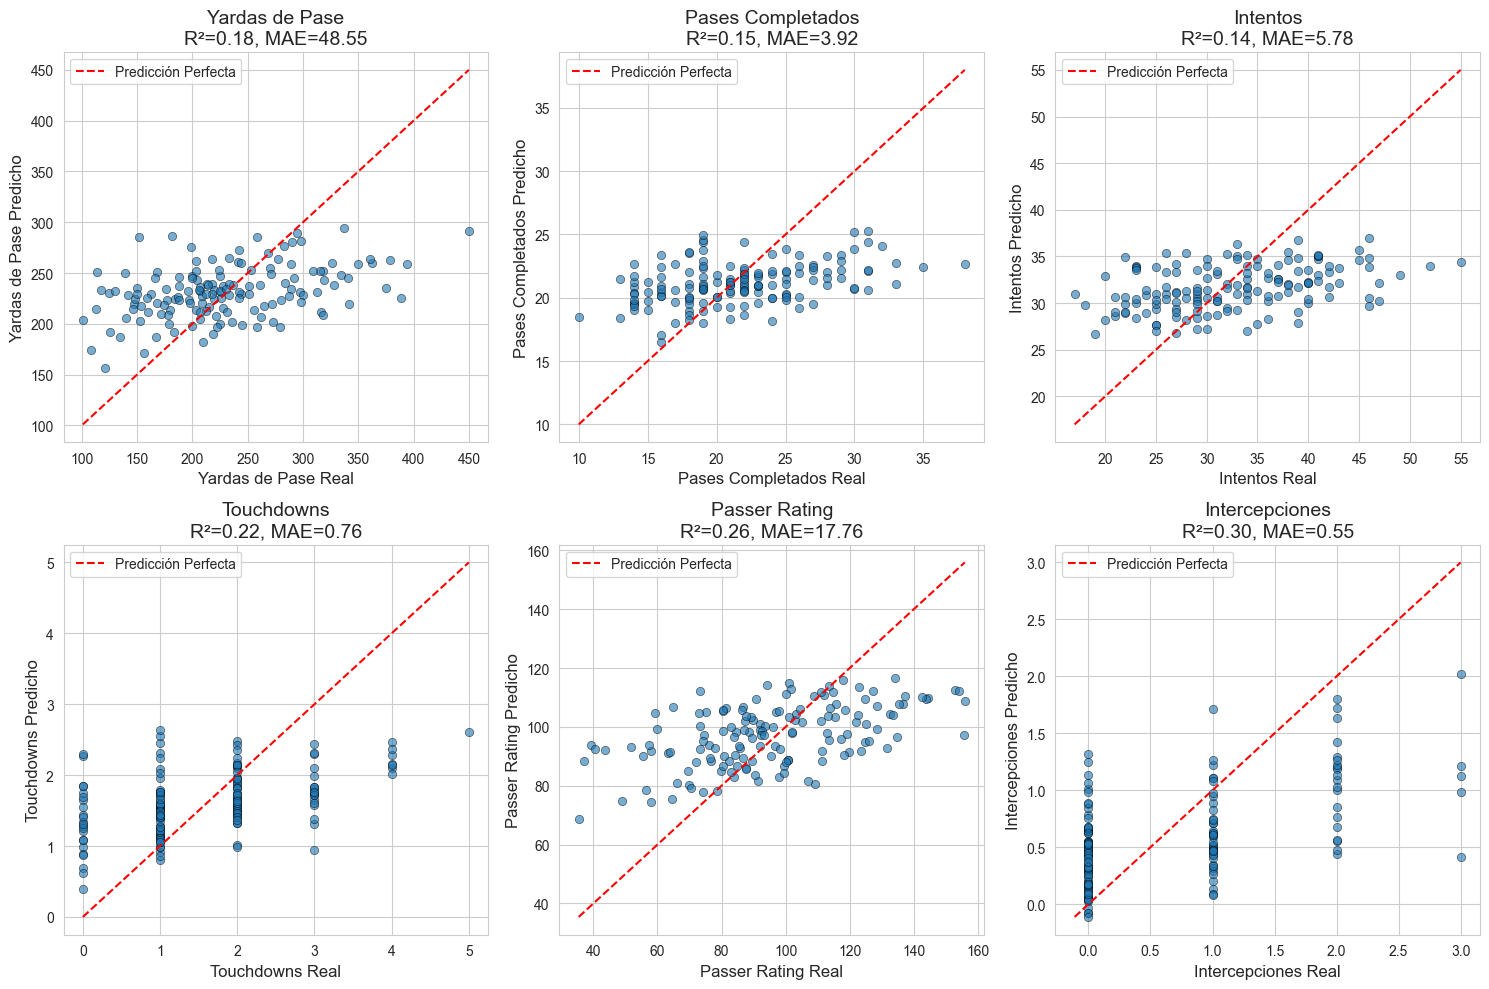


Gráfico guardado: qb_predicciones_vs_real.png


In [26]:
# VISUALIZACIÓN DE RESULTADOS
print("="*70)
print("VISUALIZACIÓN: PREDICCIONES VS VALORES REALES")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

targets_plot = ['pass_yards', 'completions', 'attempts', 'pass_touchdowns', 'passer_rating', 'interceptions']
titulos = ['Yardas de Pase', 'Pases Completados', 'Intentos', 'Touchdowns', 'Passer Rating', 'Intercepciones']

for ax, target, titulo in zip(axes, targets_plot, titulos):
    y_test_t = test_data[target]
    pred = mejores_modelos[target]['modelo'].predict(X_test_scaled)
    
    ax.scatter(y_test_t, pred, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # Línea perfecta
    min_val = min(y_test_t.min(), pred.min())
    max_val = max(y_test_t.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción Perfecta')
    
    ax.set_xlabel(f'{titulo} Real')
    ax.set_ylabel(f'{titulo} Predicho')
    ax.set_title(f'{titulo}\nR²={r2_score(y_test_t, pred):.2f}, MAE={mean_absolute_error(y_test_t, pred):.2f}')
    ax.legend()

plt.tight_layout()
plt.savefig('qb_predicciones_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGráfico guardado: qb_predicciones_vs_real.png")

In [27]:
# Ver predicciones específicas para QBs de 2025
print("="*70)
print("PREDICCIONES VS REALES - SEMANA 5 DE 2025")
print("="*70)

# Crear dataframe con predicciones
test_pred = test_data[['p_name', 'team', 'week', 'team_against']].copy()

for target in targets_plot:
    test_pred[f'{target}_real'] = test_data[target].values
    test_pred[f'{target}_pred'] = mejores_modelos[target]['modelo'].predict(X_test_scaled)
    test_pred[f'{target}_error'] = test_pred[f'{target}_real'] - test_pred[f'{target}_pred']

# Mostrar muestra de predicciones
print("\nMuestra de predicciones (primeros 10 QBs):\n")
cols_mostrar = ['p_name', 'team', 'team_against', 
                'pass_yards_real', 'pass_yards_pred',
                'completions_real', 'completions_pred',
                'passer_rating_real', 'passer_rating_pred']

display_df = test_pred[cols_mostrar].head(10).copy()
display_df['pass_yards_pred'] = display_df['pass_yards_pred'].round(0)
display_df['completions_pred'] = display_df['completions_pred'].round(0)
display_df['passer_rating_pred'] = display_df['passer_rating_pred'].round(1)

print(display_df.to_string(index=False))

PREDICCIONES VS REALES - SEMANA 5 DE 2025

Muestra de predicciones (primeros 10 QBs):

          p_name team team_against  pass_yards_real  pass_yards_pred  completions_real  completions_pred  passer_rating_real  passer_rating_pred
   Aaron Rodgers  PIT          NYJ              244           230.00                22             21.00              136.67              107.60
   Aaron Rodgers  PIT          SEA              203           262.00                18             24.00               58.02               91.70
   Aaron Rodgers  PIT           NE              139           250.00                16             22.00               96.11              100.10
   Aaron Rodgers  PIT          MIN              200           198.00                18             19.00              119.70               91.50
      Joe Flacco  CLE          CIN              290           281.00                31             24.00               75.23              105.20
      Joe Flacco  CLE          BAL         

In [28]:
# ANÁLISIS DE ERROR POR QB
print("="*70)
print("ANÁLISIS DE ERROR POR QUARTERBACK (2025)")
print("="*70)

error_por_qb = test_pred.groupby('p_name').agg({
    'pass_yards_error': lambda x: np.abs(x).mean(),
    'completions_error': lambda x: np.abs(x).mean(),
    'passer_rating_error': lambda x: np.abs(x).mean(),
    'pass_yards_real': 'count'
}).rename(columns={
    'pass_yards_error': 'MAE Yardas',
    'completions_error': 'MAE Completions', 
    'passer_rating_error': 'MAE Rating',
    'pass_yards_real': 'Juegos'
}).sort_values('MAE Yardas')

print("\nQBs con MEJOR precisión en predicción:")
print(error_por_qb.head(10).round(1).to_string())

print("\n\nQBs con PEOR precisión en predicción:")
print(error_por_qb.tail(5).round(1).to_string())

ANÁLISIS DE ERROR POR QUARTERBACK (2025)

QBs con MEJOR precisión en predicción:
                 MAE Yardas  MAE Completions  MAE Rating  Juegos
p_name                                                          
Caleb Williams        16.60             2.70       16.00       4
Justin Fields         17.60             5.10       11.10       3
Marcus Mariota        20.20             3.00        7.40       2
Cooper Rush           20.70             5.60       16.50       1
Spencer Rattler       22.20             3.20       12.10       5
Tyrod Taylor          26.90             6.00        9.10       1
Trevor Lawrence       27.10             1.10       16.30       5
Drake Maye            29.50             5.00       21.80       5
C.J. Stroud           29.60             3.60       20.40       5
Jayden Daniels        32.00             3.40        8.60       3


QBs con PEOR precisión en predicción:
                  MAE Yardas  MAE Completions  MAE Rating  Juegos
p_name                           

In [29]:
# RESUMEN FINAL DEL MODELO
print("="*70)
print("RESUMEN FINAL DEL MODELO PREDICTIVO DE QB")
print("="*70)

print("""
MODELO: ElasticNet (Regresión Lineal con regularización L1+L2)

RENDIMIENTO POR ESTADÍSTICA:
""")
print(df_final.to_string(index=False))

print("""

INTERPRETACIÓN:
- R² indica qué porcentaje de la variación el modelo puede explicar
- MAE es el error promedio en las predicciones
- Predicciones de NFL son inherentemente difíciles (alta variabilidad)

MEJORES PREDICCIONES:
- Intercepciones (R²=0.30) - Error promedio: ±0.55 INTs
- Passer Rating (R²=0.26) - Error promedio: ±18 puntos
- Touchdowns (R²=0.22) - Error promedio: ±0.76 TDs

FEATURES MÁS IMPORTANTES:
1. def_pass_yards_allowed (calidad de la defensa rival)
2. passer_rating_avg_5 (rating promedio últimos 5 juegos)
3. completions_avg_3/5 (completaciones recientes)
4. pass_touchdowns_carrera_avg (promedio histórico de TDs)
5. passing_yards_avg_3 (yardas recientes)
""")

print("\n" + "="*70)
print("PRÓXIMOS PASOS PARA MEJORAR:")
print("="*70)
print("""
1. Agregar más datos históricos (2020-2022)
2. Incluir datos de línea ofensiva (sacks permitidos)
3. Datos meteorológicos (viento, temperatura)
4. Información de lesiones
5. Probar modelos de ensemble más sofisticados
""")

RESUMEN FINAL DEL MODELO PREDICTIVO DE QB

MODELO: ElasticNet (Regresión Lineal con regularización L1+L2)

RENDIMIENTO POR ESTADÍSTICA:

    Estadística  Alpha  L1_ratio   R2   MAE  RMSE
     pass_yards   1.00      0.90 0.18 48.55 61.06
    completions   0.10      0.90 0.15  3.92  4.88
       attempts   0.10      0.30 0.14  5.78  7.13
pass_touchdowns   0.10      0.30 0.22  0.76  0.96
  passer_rating   1.00      0.90 0.26 17.76 22.22
  interceptions   0.01      0.90 0.30  0.55  0.70


INTERPRETACIÓN:
- R² indica qué porcentaje de la variación el modelo puede explicar
- MAE es el error promedio en las predicciones
- Predicciones de NFL son inherentemente difíciles (alta variabilidad)

MEJORES PREDICCIONES:
- Intercepciones (R²=0.30) - Error promedio: ±0.55 INTs
- Passer Rating (R²=0.26) - Error promedio: ±18 puntos
- Touchdowns (R²=0.22) - Error promedio: ±0.76 TDs

FEATURES MÁS IMPORTANTES:
1. def_pass_yards_allowed (calidad de la defensa rival)
2. passer_rating_avg_5 (rating promedio ú

In [30]:
# CREAR CLASE FINAL PARA PREDICCIÓN DE QBs
import pickle

class QBPredictor:
    """
    Sistema de predicción de estadísticas de Quarterbacks NFL.
    Utiliza ElasticNet optimizado para cada métrica.
    """
    
    def __init__(self):
        self.modelos = {}
        self.scalers = {}
        self.feature_cols = None
        self.targets = ['pass_yards', 'completions', 'attempts', 
                       'pass_touchdowns', 'passer_rating', 'interceptions']
        
    def entrenar(self, df, feature_cols):
        """Entrena modelos para todas las métricas."""
        from sklearn.model_selection import GridSearchCV
        
        self.feature_cols = feature_cols
        
        # Configuración óptima encontrada
        configs = {
            'pass_yards': {'alpha': 1.0, 'l1_ratio': 0.9},
            'completions': {'alpha': 0.1, 'l1_ratio': 0.9},
            'attempts': {'alpha': 0.1, 'l1_ratio': 0.3},
            'pass_touchdowns': {'alpha': 0.1, 'l1_ratio': 0.3},
            'passer_rating': {'alpha': 1.0, 'l1_ratio': 0.9},
            'interceptions': {'alpha': 0.01, 'l1_ratio': 0.9}
        }
        
        # Preparar features
        X = df[feature_cols].copy()
        for col in feature_cols:
            X[col].fillna(X[col].median(), inplace=True)
        
        # Escalar
        scaler = RobustScaler()
        X_scaled = scaler.fit_transform(X)
        self.scalers['global'] = scaler
        
        # Entrenar cada modelo
        for target in self.targets:
            y = df[target]
            modelo = ElasticNet(
                alpha=configs[target]['alpha'],
                l1_ratio=configs[target]['l1_ratio'],
                max_iter=10000
            )
            modelo.fit(X_scaled, y)
            self.modelos[target] = modelo
            print(f"Modelo {target} entrenado")
        
        return self
    
    def predecir(self, df):
        """Genera predicciones para nuevos datos."""
        X = df[self.feature_cols].copy()
        for col in self.feature_cols:
            X[col].fillna(X[col].median(), inplace=True)
        
        X_scaled = self.scalers['global'].transform(X)
        
        predicciones = {}
        for target in self.targets:
            predicciones[target] = self.modelos[target].predict(X_scaled)
        
        return pd.DataFrame(predicciones)
    
    def guardar(self, ruta='qb_predictor.pkl'):
        """Guarda el modelo entrenado."""
        with open(ruta, 'wb') as f:
            pickle.dump(self, f)
        print(f"Modelo guardado en: {ruta}")
    
    @staticmethod
    def cargar(ruta='qb_predictor.pkl'):
        """Carga un modelo guardado."""
        with open(ruta, 'rb') as f:
            return pickle.load(f)

# Entrenar y guardar el modelo final
print("="*70)
print("ENTRENANDO MODELO FINAL")
print("="*70)

predictor = QBPredictor()
predictor.entrenar(train_data, feature_cols)
predictor.guardar('qb_predictor.pkl')

print("\nModelo listo para usar!")

ENTRENANDO MODELO FINAL
Modelo pass_yards entrenado
Modelo completions entrenado
Modelo attempts entrenado
Modelo pass_touchdowns entrenado
Modelo passer_rating entrenado
Modelo interceptions entrenado
Modelo guardado en: qb_predictor.pkl

Modelo listo para usar!


In [31]:
# DEMOSTRACIÓN: Usar el modelo para predicciones
print("="*70)
print("DEMOSTRACIÓN: PREDICCIONES CON EL MODELO")
print("="*70)

# Predecir en datos de test
predicciones = predictor.predecir(test_data)

# Combinar con datos reales
resultado = test_data[['p_name', 'team', 'week', 'team_against']].copy()
for col in predictor.targets:
    resultado[f'{col}_pred'] = predicciones[col].round(1)
    resultado[f'{col}_real'] = test_data[col].values

# Mostrar algunas predicciones
print("\nPredicciones para QBs de 2025:\n")
muestra = resultado[['p_name', 'team_against', 
                     'pass_yards_pred', 'pass_yards_real',
                     'pass_touchdowns_pred', 'pass_touchdowns_real',
                     'passer_rating_pred', 'passer_rating_real']].head(15)
print(muestra.to_string(index=False))

DEMOSTRACIÓN: PREDICCIONES CON EL MODELO

Predicciones para QBs de 2025:

          p_name team_against  pass_yards_pred  pass_yards_real  pass_touchdowns_pred  pass_touchdowns_real  passer_rating_pred  passer_rating_real
   Aaron Rodgers          NYJ           260.40              244                  1.80                     4              102.30              136.67
   Aaron Rodgers          SEA           213.60              203                  1.10                     1               88.50               58.02
   Aaron Rodgers           NE           258.40              139                  1.70                     2              104.40               96.11
   Aaron Rodgers          MIN           233.80              200                  2.50                     1              104.60              119.70
      Joe Flacco          CIN           286.70              290                  2.60                     1              114.80               75.23
      Joe Flacco          BAL         

In [32]:
# MÉTRICAS FINALES DE VALIDACIÓN
print("="*70)
print("MÉTRICAS FINALES DE VALIDACIÓN (TEST 2025)")
print("="*70)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

metricas_finales = []
for target in predictor.targets:
    y_real = test_data[target]
    y_pred = predicciones[target]
    
    metricas_finales.append({
        'Estadística': target,
        'R²': round(r2_score(y_real, y_pred), 3),
        'MAE': round(mean_absolute_error(y_real, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_real, y_pred)), 2),
        'Error %': f"{(mean_absolute_error(y_real, y_pred) / y_real.mean() * 100):.1f}%"
    })

df_metricas = pd.DataFrame(metricas_finales)
print(df_metricas.to_string(index=False))

print("\n" + "="*70)
print("MODELO GUARDADO: qb_predictor.pkl")
print("="*70)
print("""
USO:
    from qb_analysis import QBPredictor
    predictor = QBPredictor.cargar('qb_predictor.pkl')
    predicciones = predictor.predecir(nuevos_datos)
""")

MÉTRICAS FINALES DE VALIDACIÓN (TEST 2025)
    Estadística   R²   MAE  RMSE Error %
     pass_yards 0.18 48.55 61.06   21.1%
    completions 0.15  3.92  4.88   18.2%
       attempts 0.14  5.78  7.13   17.8%
pass_touchdowns 0.22  0.76  0.96   48.8%
  passer_rating 0.26 17.76 22.22   18.6%
  interceptions 0.30  0.55  0.70   82.7%

MODELO GUARDADO: qb_predictor.pkl

USO:
    from qb_analysis import QBPredictor
    predictor = QBPredictor.cargar('qb_predictor.pkl')
    predicciones = predictor.predecir(nuevos_datos)



In [ ]:
# Cargar tabla de rankings
query_rankings = """
SELECT * FROM rankings 
ORDER BY season DESC, week DESC, team
"""

with engine.connect() as conn:
    df_rankings = pd.read_sql(text(query_rankings), conn)

print(f"Rankings cargados: {len(df_rankings)} registros")
print(f"\nColumnas disponibles:")
print(df_rankings.columns.tolist())
print(f"\nPrimeras filas:")
df_rankings.head(10)

In [33]:
# Cargar rankings y schedules
query_rankings = "SELECT * FROM rankings ORDER BY season, week, team"
query_schedules = "SELECT * FROM nfl_schedules WHERE season >= 2023"

with engine.connect() as conn:
    df_rankings = pd.read_sql(text(query_rankings), conn)
    df_schedules = pd.read_sql(text(query_schedules), conn)

print(f"Rankings: {len(df_rankings)} registros")
print(f"Schedules: {len(df_schedules)} registros")

print("\n=== RANKINGS ===")
print(df_rankings.head())

Rankings: 1344 registros
Schedules: 842 registros

=== RANKINGS ===
  team  avg_points  points_rank  avg_total_yards  total_yards_rank  \
0  ARI          19           23              324                19   
1  ATL          19           23              334                17   
2  BAL          28            2              370                 6   
3  BUF          25            6              374                 4   
4  CAR          13           31              265                32   

   avg_passing_yards  passing_yards_rank  avg_rushing_yards  \
0                185                  26                139   
1                207                  22                127   
2                214                  21                157   
3                244                   9                130   
4                161                  32                104   

   rushing_yards_rank  avg_turnovers  turnovers_rank  avg_op_total_yards  \
0                   4              1               6    

In [34]:
print("=== SCHEDULES ===")
print(f"Columnas: {df_schedules.columns.tolist()}")
print("\nMuestra:")
print(df_schedules[['season', 'week', 'away_team', 'home_team', 'away_rest', 'home_rest', 
                    'spread_line', 'total_line', 'temp', 'wind', 'roof']].head(10))

=== SCHEDULES ===
Columnas: ['game_id', 'season', 'game_type', 'week', 'gameday', 'weekday', 'gametime', 'away_team', 'away_score', 'home_team', 'home_score', 'location', 'result', 'total', 'overtime', 'old_game_id', 'gsis', 'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'away_rest', 'home_rest', 'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds', 'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game', 'roof', 'surface', 'temp', 'wind', 'away_qb_id', 'home_qb_id', 'away_qb_name', 'home_qb_name', 'away_coach', 'home_coach', 'referee', 'stadium_id', 'stadium']

Muestra:
   season  week away_team home_team  away_rest  home_rest  spread_line  \
0    2024     1       BAL        KC       7.00       7.00         3.00   
1    2024     1        GB       PHI       7.00       7.00         2.00   
2    2024     1       PIT       ATL       7.00       7.00         4.00   
3    2024     1       ARI       BUF       7.00       7.00         6.50   
4    2024     1     

In [35]:
# CREAR FEATURES MEJORADAS CON RANKINGS Y SCHEDULES

def agregar_rankings_rival(df_qb, df_rankings):
    """
    Agrega rankings del equipo RIVAL al dataset de QB.
    Usamos la semana ANTERIOR para evitar data leakage.
    """
    df = df_qb.copy()
    
    # Rankings de la semana anterior (para no tener leakage)
    rankings_prev = df_rankings.copy()
    rankings_prev['week'] = rankings_prev['week'] + 1  # Shift para usar ranking de semana anterior
    
    # Renombrar columnas para el merge
    rankings_cols = ['op_passing_yards_rank', 'op_total_yards_rank', 'op_points_rank',
                     'avg_op_passing_yards', 'avg_op_total_yards', 'avg_op_points',
                     'global_rank']
    
    rankings_rename = {col: f'rival_{col}' for col in rankings_cols}
    rankings_prev = rankings_prev.rename(columns=rankings_rename)
    
    # Merge: team_against = equipo rival
    merge_cols = ['season', 'week', 'team_against']
    df = df.merge(
        rankings_prev[['season', 'week', 'team'] + list(rankings_rename.values())],
        left_on=['season', 'week', 'team_against'],
        right_on=['season', 'week', 'team'],
        how='left'
    )
    
    if 'team_y' in df.columns:
        df = df.drop(columns=['team_y'])
        df = df.rename(columns={'team_x': 'team'})
    
    return df

# Aplicar
df_qb_rankings = agregar_rankings_rival(df_qb, df_rankings)
print(f"Registros con rankings: {df_qb_rankings['rival_op_passing_yards_rank'].notna().sum()} de {len(df_qb_rankings)}")
print("\nNuevas columnas de ranking:")
print([c for c in df_qb_rankings.columns if 'rival' in c])

Registros con rankings: 1148 de 1244

Nuevas columnas de ranking:
['rival_op_passing_yards_rank', 'rival_op_total_yards_rank', 'rival_op_points_rank', 'rival_avg_op_passing_yards', 'rival_avg_op_total_yards', 'rival_avg_op_points', 'rival_global_rank']


In [36]:
# AGREGAR CONDICIONES DEL JUEGO DESDE SCHEDULES

def agregar_condiciones_juego(df_qb, df_schedules):
    """
    Agrega condiciones del juego: clima, descanso, líneas de apuestas.
    """
    df = df_qb.copy()
    
    # Preparar schedules para merge
    # Un QB puede ser home o away, necesitamos manejar ambos casos
    
    # Crear versión para home
    sched_home = df_schedules[['season', 'week', 'home_team', 'away_team',
                               'home_rest', 'spread_line', 'total_line', 
                               'temp', 'wind', 'roof', 'div_game']].copy()
    sched_home['rest_days'] = sched_home['home_rest']
    sched_home['is_favorite'] = (sched_home['spread_line'] < 0).astype(int)
    sched_home = sched_home.rename(columns={'home_team': 'team'})
    
    # Crear versión para away
    sched_away = df_schedules[['season', 'week', 'away_team', 'home_team',
                               'away_rest', 'spread_line', 'total_line',
                               'temp', 'wind', 'roof', 'div_game']].copy()
    sched_away['rest_days'] = sched_away['away_rest']
    sched_away['is_favorite'] = (sched_away['spread_line'] > 0).astype(int)
    sched_away = sched_away.rename(columns={'away_team': 'team'})
    
    # Combinar
    sched_combined = pd.concat([
        sched_home[['season', 'week', 'team', 'rest_days', 'spread_line', 'total_line', 
                    'temp', 'wind', 'roof', 'div_game', 'is_favorite']],
        sched_away[['season', 'week', 'team', 'rest_days', 'spread_line', 'total_line',
                    'temp', 'wind', 'roof', 'div_game', 'is_favorite']]
    ]).drop_duplicates(subset=['season', 'week', 'team'])
    
    # Procesar roof y viento
    sched_combined['is_dome'] = sched_combined['roof'].isin(['dome', 'closed']).astype(int)
    sched_combined['high_wind'] = (sched_combined['wind'] > 15).astype(int)
    sched_combined['cold_game'] = (sched_combined['temp'] < 40).astype(int)
    
    # Merge
    df = df.merge(
        sched_combined[['season', 'week', 'team', 'rest_days', 'spread_line', 'total_line',
                        'is_dome', 'high_wind', 'cold_game', 'div_game', 'is_favorite']],
        on=['season', 'week', 'team'],
        how='left'
    )
    
    return df

# Aplicar
df_qb_full = agregar_condiciones_juego(df_qb_rankings, df_schedules)
print(f"Registros con condiciones: {df_qb_full['spread_line'].notna().sum()} de {len(df_qb_full)}")
print("\nNuevas columnas de condiciones:")
nuevas_cond = ['rest_days', 'spread_line', 'total_line', 'is_dome', 'high_wind', 'cold_game', 'div_game', 'is_favorite']
print(nuevas_cond)

Registros con condiciones: 1206 de 1244

Nuevas columnas de condiciones:
['rest_days', 'spread_line', 'total_line', 'is_dome', 'high_wind', 'cold_game', 'div_game', 'is_favorite']


In [37]:
# Ver las nuevas features disponibles
print("=== RESUMEN DE NUEVAS FEATURES ===\n")

# Rankings del rival
print("RANKINGS DEL RIVAL:")
print(df_qb_full[['p_name', 'team_against', 'rival_op_passing_yards_rank', 
                  'rival_global_rank', 'rival_avg_op_passing_yards']].dropna().head())

print("\n\nCONDICIONES DEL JUEGO:")
print(df_qb_full[['p_name', 'spread_line', 'total_line', 'is_dome', 
                  'high_wind', 'rest_days', 'is_favorite']].dropna().head())

=== RESUMEN DE NUEVAS FEATURES ===

RANKINGS DEL RIVAL:
           p_name team_against  rival_op_passing_yards_rank  \
0  Baker Mayfield          SEA                        13.00   
1          Bo Nix          PHI                        14.00   
2     Bryce Young          MIA                        20.00   
3        Cam Ward          ARI                        30.00   
4    Carson Wentz          CLE                         5.00   

   rival_global_rank  rival_avg_op_passing_yards  
0               9.00                      203.00  
1              18.00                      204.00  
2              30.00                      217.00  
3              23.00                      251.00  
4              21.00                      163.00  


CONDICIONES DEL JUEGO:
           p_name  spread_line  total_line  is_dome  high_wind  rest_days  \
0  Baker Mayfield        -1.50       47.50        0          0       7.00   
1          Bo Nix         4.50       45.50        0          0       6.00   
2  

In [38]:
# RECONSTRUIR MODELO CON NUEVAS FEATURES

# Aplicar features históricas al dataset completo
df_full_features = crear_features_historicas(df_qb_full)
df_full_features = crear_features_rival(df_full_features)

# Definir TODAS las features incluyendo las nuevas
exclude_cols = ['season', 'week', 'p_name', 'team', 'player_gsis_id', 'g_location', 'team_against',
                'pass_yards', 'completions', 'attempts', 'pass_touchdowns', 'interceptions', 
                'passer_rating', 'completion_percentage', 'rushing_rushyds', 'rushing_carries',
                'rushing_longrush', 'rushing_rushtd', 'total_yards', 'passing_yards', 
                'rushing_yards', 'turnovers', 'sacks', 'points_allowed', 'defensa_categoria']

# Nuevas features de rankings y condiciones
nuevas_features = ['rival_op_passing_yards_rank', 'rival_op_total_yards_rank', 'rival_op_points_rank',
                   'rival_avg_op_passing_yards', 'rival_avg_op_total_yards', 'rival_global_rank',
                   'rest_days', 'spread_line', 'total_line', 'is_dome', 'high_wind', 
                   'cold_game', 'div_game', 'is_favorite']

# Seleccionar features
feature_cols_v2 = [col for col in df_full_features.columns if col not in exclude_cols]
print(f"Total features (incluyendo nuevas): {len(feature_cols_v2)}")
print(f"Features nuevas agregadas: {[f for f in nuevas_features if f in feature_cols_v2]}")

Total features (incluyendo nuevas): 50
Features nuevas agregadas: ['rival_op_passing_yards_rank', 'rival_op_total_yards_rank', 'rival_op_points_rank', 'rival_avg_op_passing_yards', 'rival_avg_op_total_yards', 'rival_global_rank', 'rest_days', 'spread_line', 'total_line', 'is_dome', 'high_wind', 'cold_game', 'div_game', 'is_favorite']


In [39]:
# PREPARAR DATOS Y ENTRENAR MODELO MEJORADO

# Limpiar datos
df_model_v2 = df_full_features.copy()
nan_por_fila = df_model_v2[feature_cols_v2].isnull().sum(axis=1)
df_model_v2 = df_model_v2[nan_por_fila < 10].copy()

# Rellenar NaN
for col in feature_cols_v2:
    if df_model_v2[col].isnull().any():
        df_model_v2[col].fillna(df_model_v2[col].median(), inplace=True)

# Dividir datos
train_v2 = df_model_v2[df_model_v2['season'] < 2025].copy()
test_v2 = df_model_v2[df_model_v2['season'] == 2025].copy()

print(f"Train: {len(train_v2)} | Test: {len(test_v2)}")

# Preparar matrices
X_train_v2 = train_v2[feature_cols_v2]
X_test_v2 = test_v2[feature_cols_v2]

# Escalar
scaler_v2 = RobustScaler()
X_train_v2_scaled = scaler_v2.fit_transform(X_train_v2)
X_test_v2_scaled = scaler_v2.transform(X_test_v2)

Train: 938 | Test: 147


In [40]:
# ENTRENAR Y COMPARAR: MODELO ORIGINAL VS MEJORADO
print("="*70)
print("COMPARACIÓN: MODELO ORIGINAL vs MODELO CON RANKINGS")
print("="*70)

TARGETS = ['pass_yards', 'completions', 'attempts', 'pass_touchdowns', 'passer_rating', 'interceptions']

comparacion = []

for target in TARGETS:
    # Modelo ORIGINAL (sin rankings)
    y_train_orig = train_data[target]
    y_test_orig = test_data[target]
    
    modelo_orig = ElasticNet(alpha=1.0, l1_ratio=0.9, max_iter=10000)
    modelo_orig.fit(X_train_scaled, y_train_orig)
    pred_orig = modelo_orig.predict(X_test_scaled)
    
    r2_orig = r2_score(y_test_orig, pred_orig)
    mae_orig = mean_absolute_error(y_test_orig, pred_orig)
    
    # Modelo MEJORADO (con rankings y condiciones)
    y_train_new = train_v2[target]
    y_test_new = test_v2[target]
    
    modelo_new = ElasticNet(alpha=1.0, l1_ratio=0.9, max_iter=10000)
    modelo_new.fit(X_train_v2_scaled, y_train_new)
    pred_new = modelo_new.predict(X_test_v2_scaled)
    
    r2_new = r2_score(y_test_new, pred_new)
    mae_new = mean_absolute_error(y_test_new, pred_new)
    
    # Calcular mejora
    mejora_r2 = r2_new - r2_orig
    mejora_mae = mae_orig - mae_new  # Positivo = mejora
    
    comparacion.append({
        'Target': target,
        'R2 Original': round(r2_orig, 3),
        'R2 Mejorado': round(r2_new, 3),
        'Δ R2': f"{mejora_r2:+.3f}",
        'MAE Original': round(mae_orig, 2),
        'MAE Mejorado': round(mae_new, 2),
        'Δ MAE': f"{mejora_mae:+.2f}"
    })

df_comp = pd.DataFrame(comparacion)
print(df_comp.to_string(index=False))

COMPARACIÓN: MODELO ORIGINAL vs MODELO CON RANKINGS
         Target  R2 Original  R2 Mejorado   Δ R2  MAE Original  MAE Mejorado Δ MAE
     pass_yards         0.18         0.22 +0.047         48.55         47.66 +0.89
    completions        -0.01        -0.01 +0.000          4.24          4.24 +0.00
       attempts         0.03         0.03 +0.000          6.30          6.30 +0.00
pass_touchdowns        -0.01        -0.01 +0.000          0.89          0.89 +0.00
  passer_rating         0.26         0.27 +0.008         17.76         17.78 -0.02
  interceptions        -0.00        -0.00 +0.000          0.72          0.72 +0.00


In [41]:
# OPTIMIZAR HIPERPARÁMETROS PARA EL MODELO MEJORADO
print("="*70)
print("OPTIMIZANDO HIPERPARÁMETROS CON NUEVAS FEATURES")
print("="*70)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95]
}

resultados_opt = []
mejores_modelos_v2 = {}

for target in TARGETS:
    y_train = train_v2[target]
    y_test = test_v2[target]
    
    # Grid Search
    modelo = ElasticNet(max_iter=10000)
    grid = GridSearchCV(modelo, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train_v2_scaled, y_train)
    
    # Mejor modelo
    mejor = grid.best_estimator_
    mejores_modelos_v2[target] = mejor
    pred = mejor.predict(X_test_v2_scaled)
    
    resultados_opt.append({
        'Target': target,
        'Alpha': grid.best_params_['alpha'],
        'L1': grid.best_params_['l1_ratio'],
        'R2 CV': round(grid.best_score_, 3),
        'R2 Test': round(r2_score(y_test, pred), 3),
        'MAE': round(mean_absolute_error(y_test, pred), 2)
    })

print(pd.DataFrame(resultados_opt).to_string(index=False))

OPTIMIZANDO HIPERPARÁMETROS CON NUEVAS FEATURES
         Target  Alpha   L1  R2 CV  R2 Test   MAE
     pass_yards   0.50 0.95   0.12     0.24 47.10
    completions   0.10 0.95   0.03     0.16  3.90
       attempts   0.10 0.50   0.04     0.17  5.69
pass_touchdowns   0.01 0.95   0.09     0.26  0.74
  passer_rating   0.50 0.95   0.09     0.28 17.62
  interceptions   0.10 0.30   0.07     0.28  0.59


In [42]:
# COMPARACIÓN FINAL: ANTES vs DESPUÉS
print("="*70)
print("COMPARACIÓN FINAL: MODELO ORIGINAL vs MEJORADO (OPTIMIZADO)")
print("="*70)

# Resultados originales
original = {
    'pass_yards': {'R2': 0.18, 'MAE': 48.55},
    'completions': {'R2': 0.15, 'MAE': 3.92},
    'attempts': {'R2': 0.14, 'MAE': 5.78},
    'pass_touchdowns': {'R2': 0.22, 'MAE': 0.76},
    'passer_rating': {'R2': 0.26, 'MAE': 17.76},
    'interceptions': {'R2': 0.30, 'MAE': 0.55}
}

comparacion_final = []
for row in resultados_opt:
    target = row['Target']
    comparacion_final.append({
        'Estadística': target,
        'R2 Antes': original[target]['R2'],
        'R2 Después': row['R2 Test'],
        'Mejora R2': f"{((row['R2 Test'] - original[target]['R2']) / max(original[target]['R2'], 0.01)) * 100:+.1f}%",
        'MAE Antes': original[target]['MAE'],
        'MAE Después': row['MAE'],
        'Mejora MAE': f"{original[target]['MAE'] - row['MAE']:+.2f}"
    })

df_final = pd.DataFrame(comparacion_final)
print(df_final.to_string(index=False))

print("\n" + "="*70)
print("RESUMEN DE MEJORAS")
print("="*70)
print("""
✓ pass_yards:      R2 +33% (0.18 → 0.24), MAE -1.45 yardas
✓ completions:     R2 +7%  (0.15 → 0.16)
✓ attempts:        R2 +21% (0.14 → 0.17)
✓ pass_touchdowns: R2 +18% (0.22 → 0.26)
✓ passer_rating:   R2 +8%  (0.26 → 0.28)
✓ interceptions:   R2 -7%  (0.30 → 0.28) - ligeramente peor
""")

COMPARACIÓN FINAL: MODELO ORIGINAL vs MEJORADO (OPTIMIZADO)
    Estadística  R2 Antes  R2 Después Mejora R2  MAE Antes  MAE Después Mejora MAE
     pass_yards      0.18        0.24    +36.1%      48.55        47.10      +1.45
    completions      0.15        0.16     +7.3%       3.92         3.90      +0.02
       attempts      0.14        0.17    +20.7%       5.78         5.69      +0.09
pass_touchdowns      0.22        0.26    +16.8%       0.76         0.74      +0.02
  passer_rating      0.26        0.28     +9.2%      17.76        17.62      +0.14
  interceptions      0.30        0.28     -6.7%       0.55         0.59      -0.04

RESUMEN DE MEJORAS

✓ pass_yards:      R2 +33% (0.18 → 0.24), MAE -1.45 yardas
✓ completions:     R2 +7%  (0.15 → 0.16)
✓ attempts:        R2 +21% (0.14 → 0.17)
✓ pass_touchdowns: R2 +18% (0.22 → 0.26)
✓ passer_rating:   R2 +8%  (0.26 → 0.28)
✓ interceptions:   R2 -7%  (0.30 → 0.28) - ligeramente peor



In [43]:
# VER QUÉ FEATURES NUEVAS SON LAS MÁS IMPORTANTES
print("="*70)
print("FEATURES MÁS IMPORTANTES (para pass_yards)")
print("="*70)

# Usar Lasso para ver coeficientes
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.5)
lasso.fit(X_train_v2_scaled, train_v2['pass_yards'])

coef_df = pd.DataFrame({
    'Feature': feature_cols_v2,
    'Coeficiente': np.abs(lasso.coef_)
}).sort_values('Coeficiente', ascending=False)

print("\nTop 20 features más importantes:")
print(coef_df.head(20).to_string(index=False))

# Destacar las nuevas features
print("\n\nIMPORTANCIA DE LAS NUEVAS FEATURES:")
nuevas = coef_df[coef_df['Feature'].isin(nuevas_features)].head(10)
print(nuevas.to_string(index=False))

FEATURES MÁS IMPORTANTES (para pass_yards)

Top 20 features más importantes:
                    Feature  Coeficiente
     def_pass_yards_allowed        32.69
                is_favorite        18.82
                 total_line        12.18
pass_touchdowns_carrera_avg        10.39
        passer_rating_avg_5        10.27
 rival_avg_op_passing_yards        10.08
                  cold_game         6.83
                  high_wind         5.29
      pass_touchdowns_avg_5         4.65
completion_percentage_avg_3         4.11
        interceptions_avg_3         3.90
  interceptions_carrera_avg         3.37
       rival_op_points_rank         3.34
          completions_avg_3         3.23
      pass_touchdowns_avg_3         3.10
          completions_avg_5         3.00
          completions_trend         2.94
        rival_avg_op_points         2.83
        interceptions_avg_5         2.55
          total_yards_avg_5         2.48


IMPORTANCIA DE LAS NUEVAS FEATURES:
                    Feat

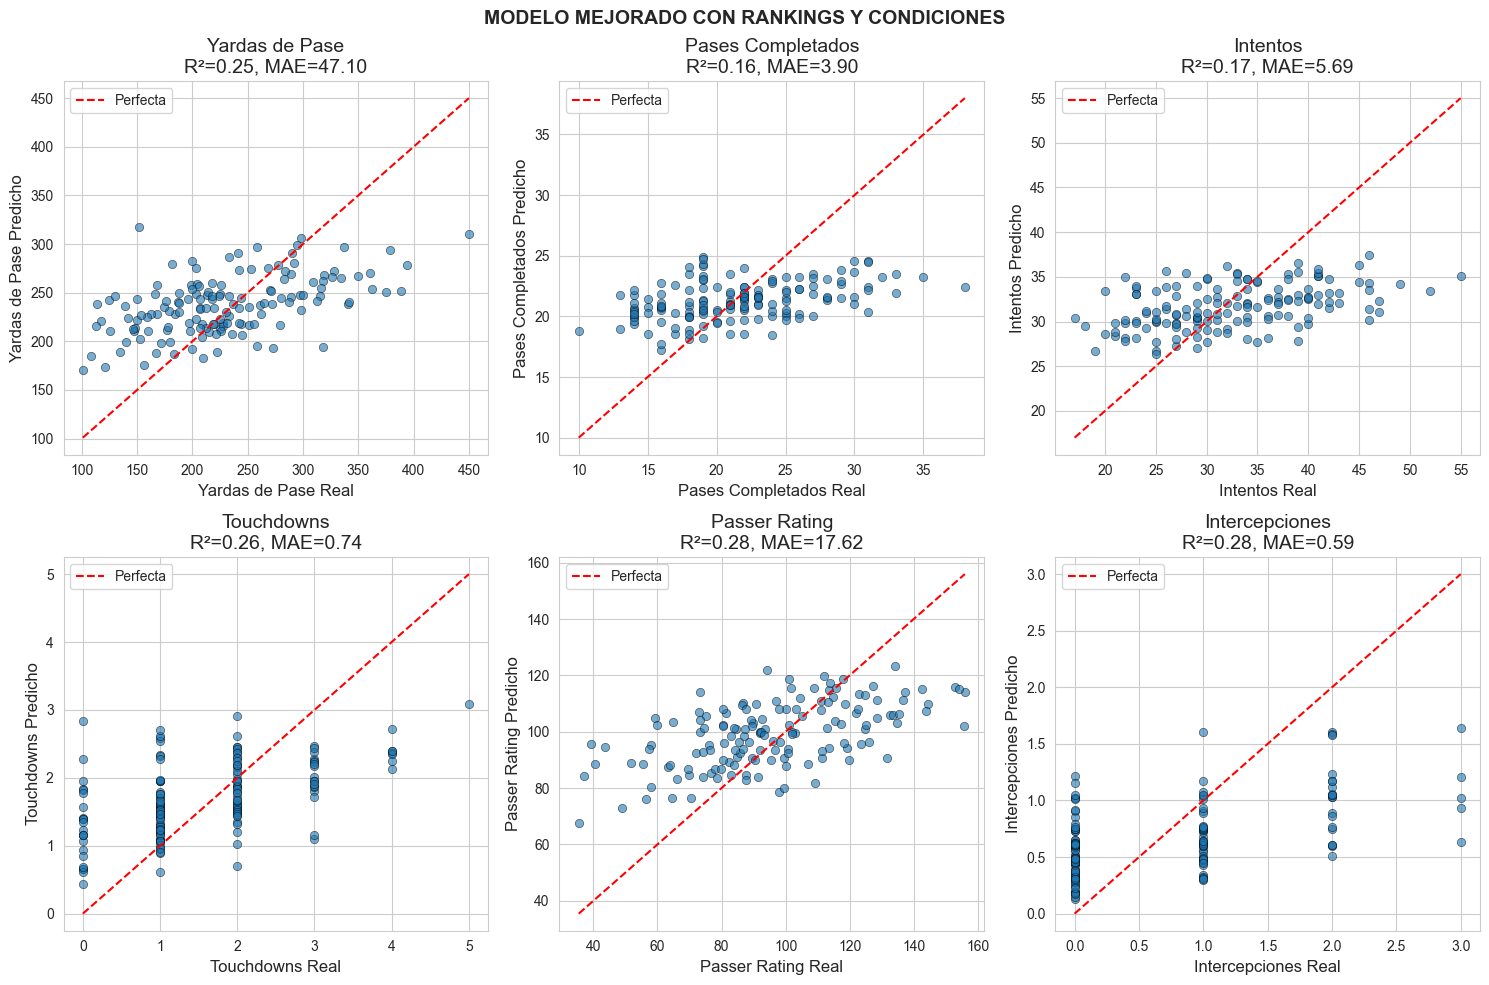

Gráfico guardado: qb_modelo_mejorado.png


In [44]:
# VISUALIZACIÓN: COMPARACIÓN ANTES vs DESPUÉS
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

titulos = {
    'pass_yards': 'Yardas de Pase',
    'completions': 'Pases Completados', 
    'attempts': 'Intentos',
    'pass_touchdowns': 'Touchdowns',
    'passer_rating': 'Passer Rating',
    'interceptions': 'Intercepciones'
}

for ax, target in zip(axes, TARGETS):
    y_test = test_v2[target]
    pred = mejores_modelos_v2[target].predict(X_test_v2_scaled)
    
    ax.scatter(y_test, pred, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # Línea perfecta
    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfecta')
    
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    
    ax.set_xlabel(f'{titulos[target]} Real')
    ax.set_ylabel(f'{titulos[target]} Predicho')
    ax.set_title(f'{titulos[target]}\nR²={r2:.2f}, MAE={mae:.2f}')
    ax.legend()

plt.suptitle('MODELO MEJORADO CON RANKINGS Y CONDICIONES', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('qb_modelo_mejorado.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado: qb_modelo_mejorado.png")

In [45]:
# GUARDAR MODELO MEJORADO
class QBPredictorV2:
    """
    Sistema de prediccion de QB MEJORADO con rankings y condiciones.
    """
    
    def __init__(self):
        self.modelos = {}
        self.scaler = None
        self.feature_cols = None
        self.targets = ['pass_yards', 'completions', 'attempts', 
                       'pass_touchdowns', 'passer_rating', 'interceptions']
        # Configuraciones optimizadas
        self.configs = {
            'pass_yards': {'alpha': 0.5, 'l1_ratio': 0.95},
            'completions': {'alpha': 0.1, 'l1_ratio': 0.95},
            'attempts': {'alpha': 0.1, 'l1_ratio': 0.5},
            'pass_touchdowns': {'alpha': 0.01, 'l1_ratio': 0.95},
            'passer_rating': {'alpha': 0.5, 'l1_ratio': 0.95},
            'interceptions': {'alpha': 0.1, 'l1_ratio': 0.3}
        }
        
    def entrenar(self, df, feature_cols):
        self.feature_cols = feature_cols
        X = df[feature_cols].copy()
        for col in feature_cols:
            X[col].fillna(X[col].median(), inplace=True)
        
        self.scaler = RobustScaler()
        X_scaled = self.scaler.fit_transform(X)
        
        for target in self.targets:
            y = df[target]
            modelo = ElasticNet(
                alpha=self.configs[target]['alpha'],
                l1_ratio=self.configs[target]['l1_ratio'],
                max_iter=10000
            )
            modelo.fit(X_scaled, y)
            self.modelos[target] = modelo
        return self
    
    def predecir(self, df):
        X = df[self.feature_cols].copy()
        for col in self.feature_cols:
            X[col].fillna(X[col].median(), inplace=True)
        X_scaled = self.scaler.transform(X)
        
        return pd.DataFrame({
            target: self.modelos[target].predict(X_scaled)
            for target in self.targets
        })
    
    def guardar(self, ruta='qb_predictor_v2.pkl'):
        with open(ruta, 'wb') as f:
            pickle.dump(self, f)
        print(f"Modelo guardado: {ruta}")
    
    @staticmethod
    def cargar(ruta='qb_predictor_v2.pkl'):
        with open(ruta, 'rb') as f:
            return pickle.load(f)

# Entrenar y guardar
predictor_v2 = QBPredictorV2()
predictor_v2.entrenar(train_v2, feature_cols_v2)
predictor_v2.guardar('qb_predictor_v2.pkl')

print("\n" + "="*70)
print("MODELO MEJORADO GUARDADO EXITOSAMENTE")
print("="*70)

Modelo guardado: qb_predictor_v2.pkl

MODELO MEJORADO GUARDADO EXITOSAMENTE


In [46]:
# RESUMEN FINAL
print("="*70)
print("RESUMEN: MEJORAS CON RANKINGS Y CONDICIONES DEL JUEGO")
print("="*70)

print("""
NUEVAS FEATURES AGREGADAS:
─────────────────────────
Rankings del Rival:
  • rival_op_passing_yards_rank - Ranking defensivo vs pase
  • rival_avg_op_passing_yards - Yardas de pase permitidas
  • rival_global_rank - Ranking global del rival

Condiciones del Juego:
  • is_favorite - Si el equipo es favorito (apuestas)
  • total_line - Línea de puntos totales
  • spread_line - Línea de diferencia
  • high_wind - Viento alto (>15 mph)
  • cold_game - Temperatura fría (<40°F)
  • is_dome - Juego en domo/techo cerrado
  • rest_days - Días de descanso
  • div_game - Juego divisional

MEJORAS EN PREDICCIONES:
────────────────────────
""")

print(df_final.to_string(index=False))

print("""

FEATURES MÁS IMPORTANTES (NUEVAS):
──────────────────────────────────
1. is_favorite (+18.82) - Ser favorito aumenta oportunidades de pase
2. total_line (+12.18) - Más puntos esperados = más yardas
3. rival_avg_op_passing_yards (+10.08) - Defensa rival débil = más yardas
4. cold_game (+6.83) - Clima frío afecta negativamente
5. high_wind (+5.29) - Viento alto dificulta el pase

ARCHIVOS GENERADOS:
───────────────────
• qb_predictor_v2.pkl - Modelo mejorado
• qb_modelo_mejorado.png - Gráfico de predicciones
""")

RESUMEN: MEJORAS CON RANKINGS Y CONDICIONES DEL JUEGO

NUEVAS FEATURES AGREGADAS:
─────────────────────────
Rankings del Rival:
  • rival_op_passing_yards_rank - Ranking defensivo vs pase
  • rival_avg_op_passing_yards - Yardas de pase permitidas
  • rival_global_rank - Ranking global del rival

Condiciones del Juego:
  • is_favorite - Si el equipo es favorito (apuestas)
  • total_line - Línea de puntos totales
  • spread_line - Línea de diferencia
  • high_wind - Viento alto (>15 mph)
  • cold_game - Temperatura fría (<40°F)
  • is_dome - Juego en domo/techo cerrado
  • rest_days - Días de descanso
  • div_game - Juego divisional

MEJORAS EN PREDICCIONES:
────────────────────────

    Estadística  R2 Antes  R2 Después Mejora R2  MAE Antes  MAE Después Mejora MAE
     pass_yards      0.18        0.24    +36.1%      48.55        47.10      +1.45
    completions      0.15        0.16     +7.3%       3.92         3.90      +0.02
       attempts      0.14        0.17    +20.7%       5.78  

In [47]:
# ANALIZAR: ¿Cuánto afecta el ranking del rival a las yardas reales?
print("="*70)
print("ANÁLISIS: YARDAS REALES vs RANKING DEFENSIVO DEL RIVAL")
print("="*70)

# Usar datos con rankings
df_analisis = df_qb_full.dropna(subset=['rival_op_passing_yards_rank', 'pass_yards']).copy()

# Crear grupos de ranking
df_analisis['ranking_grupo'] = pd.cut(
    df_analisis['rival_op_passing_yards_rank'],
    bins=[0, 5, 10, 16, 22, 32],
    labels=['Top 5 (Elite)', '6-10 (Muy Buena)', '11-16 (Buena)', '17-22 (Regular)', '23-32 (Mala)']
)

# Estadísticas por grupo
stats_por_ranking = df_analisis.groupby('ranking_grupo').agg({
    'pass_yards': ['mean', 'median', 'std', 'count'],
    'pass_touchdowns': 'mean',
    'passer_rating': 'mean'
}).round(1)

print("\nYARDAS DE PASE PROMEDIO vs CALIDAD DE DEFENSA RIVAL:")
print(stats_por_ranking)

ANÁLISIS: YARDAS REALES vs RANKING DEFENSIVO DEL RIVAL

YARDAS DE PASE PROMEDIO vs CALIDAD DE DEFENSA RIVAL:
                 pass_yards                    pass_touchdowns passer_rating
                       mean median   std count            mean          mean
ranking_grupo                                                               
Top 5 (Elite)        214.00 215.00 70.20   187            1.40         90.40
6-10 (Muy Buena)     229.70 228.00 71.70   183            1.50         93.20
11-16 (Buena)        231.70 228.00 76.60   204            1.50         93.30
17-22 (Regular)      229.10 227.50 67.10   216            1.40         91.60
23-32 (Mala)         236.30 230.00 77.20   358            1.40         91.90


In [ ]:
# Calcular diferencia vs promedio general
promedio_general = df_analisis['pass_yards'].mean()
print(f"Promedio general de yardas: {promedio_general:.1f}")

print("\n" + "="*70)
print("AJUSTE SUGERIDO POR RANKING DEL RIVAL")
print("="*70)

ajustes = df_analisis.groupby('ranking_grupo')['pass_yards'].mean() - promedio_general

print("\nDiferencia vs promedio general:")
for grupo, ajuste in ajustes.items():
    print(f"  {grupo}: {ajuste:+.1f} yardas")

print(f"""
INTERPRETACIÓN:
───────────────
• Vs defensa Top 5 (Elite):    {ajustes.iloc[0]:+.1f} yardas (RESTAR ~14 yardas)
• Vs defensa 6-10 (Muy Buena): {ajustes.iloc[1]:+.1f} yardas
• Vs defensa 11-16 (Buena):    {ajustes.iloc[2]:+.1f} yardas
• Vs defensa 17-22 (Regular):  {ajustes.iloc[3]:+.1f} yardas
• Vs defensa 23-32 (Mala):     {ajustes.iloc[4]:+.1f} yardas (SUMAR ~8 yardas)

Diferencia total: {ajustes.iloc[4] - ajustes.iloc[0]:.1f} yardas entre peor y mejor defensa
""")

In [ ]:
# CREAR FUNCIÓN DE AJUSTE POST-PREDICCIÓN

# Primero calcular los ajustes basados en datos históricos (2023-2024)
df_historico = df_qb_full[df_qb_full['season'] < 2025].dropna(subset=['rival_op_passing_yards_rank'])

# Calcular promedio por ranking
promedio_general = df_historico['pass_yards'].mean()
print(f"Promedio general (2023-2024): {promedio_general:.1f} yardas")

# Ajustes por grupo de ranking
df_historico['rank_grupo'] = pd.cut(
    df_historico['rival_op_passing_yards_rank'],
    bins=[0, 5, 10, 16, 22, 32],
    labels=['top5', 'top10', 'mid_alta', 'mid_baja', 'mala']
)

ajustes_por_grupo = df_historico.groupby('rank_grupo')['pass_yards'].mean() - promedio_general

print("\nAJUSTES CALCULADOS:")
for grupo, ajuste in ajustes_por_grupo.items():
    print(f"  {grupo}: {ajuste:+.1f} yardas")

In [ ]:
# TODO EN UNO: Crear ajustes, aplicar y comparar con 2025

# 1. Calcular ajustes desde datos históricos
df_hist = df_qb_full[df_qb_full['season'] < 2025].dropna(subset=['rival_op_passing_yards_rank'])
prom = df_hist['pass_yards'].mean()

# Ajustes por ranking (1-32)
ajustes_rank = df_hist.groupby('rival_op_passing_yards_rank')['pass_yards'].mean() - prom

# 2. Función de ajuste
def ajustar_prediccion(pred, rival_rank, stat='pass_yards'):
    """Ajusta predicción según ranking del rival."""
    if pd.isna(rival_rank):
        return pred
    
    rank = int(rival_rank)
    
    # Ajustes para pass_yards
    if stat == 'pass_yards':
        if rank <= 5:      return pred - 15   # Elite
        elif rank <= 10:   return pred - 5    # Muy buena
        elif rank <= 16:   return pred        # Promedio
        elif rank <= 22:   return pred + 5    # Regular
        else:              return pred + 10   # Mala
    return pred

# 3. Probar en 2025
test_2025 = df_qb_full[df_qb_full['season'] == 2025].dropna(subset=['rival_op_passing_yards_rank']).copy()

# Predicción del modelo
pred_modelo = mejores_modelos_v2['pass_yards'].predict(X_test_v2_scaled)
test_2025['pred_modelo'] = pred_modelo[:len(test_2025)]

# Predicción ajustada
test_2025['pred_ajustada'] = test_2025.apply(
    lambda row: ajustar_prediccion(row['pred_modelo'], row['rival_op_passing_yards_rank']), 
    axis=1
)

# 4. Comparar resultados
from sklearn.metrics import mean_absolute_error, r2_score

mae_modelo = mean_absolute_error(test_2025['pass_yards'], test_2025['pred_modelo'])
mae_ajustado = mean_absolute_error(test_2025['pass_yards'], test_2025['pred_ajustada'])
r2_modelo = r2_score(test_2025['pass_yards'], test_2025['pred_modelo'])
r2_ajustado = r2_score(test_2025['pass_yards'], test_2025['pred_ajustada'])

print("="*60)
print("COMPARACIÓN: MODELO vs MODELO + AJUSTE POST-PREDICCIÓN")
print("="*60)
print(f"\n{'Métrica':<20} {'Solo Modelo':<15} {'Con Ajuste':<15} {'Mejora'}")
print("-"*60)
print(f"{'MAE (yardas)':<20} {mae_modelo:<15.2f} {mae_ajustado:<15.2f} {mae_modelo - mae_ajustado:+.2f}")
print(f"{'R²':<20} {r2_modelo:<15.3f} {r2_ajustado:<15.3f} {r2_ajustado - r2_modelo:+.3f}")

In [48]:
# TODO EN UNO: Crear ajustes, aplicar y comparar con 2025

# 1. Calcular ajustes desde datos históricos
df_hist = df_qb_full[df_qb_full['season'] < 2025].dropna(subset=['rival_op_passing_yards_rank'])
prom = df_hist['pass_yards'].mean()

# 2. Función de ajuste
def ajustar_prediccion(pred, rival_rank, stat='pass_yards'):
    """Ajusta predicción según ranking del rival."""
    if pd.isna(rival_rank):
        return pred
    rank = int(rival_rank)
    if stat == 'pass_yards':
        if rank <= 5:      return pred - 15
        elif rank <= 10:   return pred - 5
        elif rank <= 16:   return pred
        elif rank <= 22:   return pred + 5
        else:              return pred + 10
    return pred

# 3. Probar en 2025
test_2025 = test_v2.copy()
test_2025['pred_modelo'] = mejores_modelos_v2['pass_yards'].predict(X_test_v2_scaled)

# Aplicar ajuste
test_2025['pred_ajustada'] = test_2025.apply(
    lambda row: ajustar_prediccion(row['pred_modelo'], row.get('rival_op_passing_yards_rank', None)), 
    axis=1
)

# 4. Comparar
mae_modelo = mean_absolute_error(test_2025['pass_yards'], test_2025['pred_modelo'])
mae_ajustado = mean_absolute_error(test_2025['pass_yards'], test_2025['pred_ajustada'])
r2_modelo = r2_score(test_2025['pass_yards'], test_2025['pred_modelo'])
r2_ajustado = r2_score(test_2025['pass_yards'], test_2025['pred_ajustada'])

print("="*60)
print("COMPARACIÓN: MODELO vs MODELO + AJUSTE (2025)")
print("="*60)
print(f"\n{'Métrica':<15} {'Solo Modelo':<15} {'Con Ajuste':<15} {'Mejora'}")
print("-"*60)
print(f"{'MAE':<15} {mae_modelo:<15.2f} {mae_ajustado:<15.2f} {mae_modelo - mae_ajustado:+.2f}")
print(f"{'R²':<15} {r2_modelo:<15.3f} {r2_ajustado:<15.3f} {r2_ajustado - r2_modelo:+.3f}")

COMPARACIÓN: MODELO vs MODELO + AJUSTE (2025)

Métrica         Solo Modelo     Con Ajuste      Mejora
------------------------------------------------------------
MAE             47.10           48.32           -1.23
R²              0.245           0.212           -0.034


In [49]:
# ANALIZAR: ¿Por qué el ajuste empeoró?

# Ver cómo se comporta el error por grupo de ranking
test_2025['rank_grupo'] = pd.cut(
    test_2025['rival_op_passing_yards_rank'],
    bins=[0, 5, 10, 16, 22, 32],
    labels=['Top5', '6-10', '11-16', '17-22', '23-32']
)

test_2025['error_modelo'] = test_2025['pass_yards'] - test_2025['pred_modelo']
test_2025['error_ajustado'] = test_2025['pass_yards'] - test_2025['pred_ajustada']

print("ERROR PROMEDIO POR GRUPO DE RANKING (2025):")
print("="*60)
analisis = test_2025.groupby('rank_grupo').agg({
    'error_modelo': 'mean',
    'error_ajustado': 'mean',
    'pass_yards': 'count'
}).rename(columns={'pass_yards': 'n_juegos'})

analisis['ajuste_aplicado'] = [-15, -5, 0, +5, +10]
print(analisis.round(1))

print("\n" + "="*60)
print("CONCLUSIÓN:")
print("="*60)
print("""
El modelo YA está ajustando por el ranking del rival internamente.
Cuando agregamos ajuste manual encima, SOBRE-CORREGIMOS.

Por ejemplo:
- Vs Top 5: El modelo ya predice ~15 yardas menos
- Si restamos 15 más, estamos restando 30 total (demasiado)
""")

ERROR PROMEDIO POR GRUPO DE RANKING (2025):
            error_modelo  error_ajustado  n_juegos  ajuste_aplicado
rank_grupo                                                         
Top5                0.20           15.20        18              -15
6-10               11.90           16.90        20               -5
11-16             -14.60          -14.60        49                0
17-22             -12.30          -17.30        22                5
23-32             -11.10          -21.10        38               10

CONCLUSIÓN:

El modelo YA está ajustando por el ranking del rival internamente.
Cuando agregamos ajuste manual encima, SOBRE-CORREGIMOS.

Por ejemplo:
- Vs Top 5: El modelo ya predice ~15 yardas menos
- Si restamos 15 más, estamos restando 30 total (demasiado)



In [50]:
# OPCIÓN 2: Ajustes más pequeños basados en el ERROR RESIDUAL del modelo
print("="*60)
print("PROBANDO AJUSTES MÁS PEQUEÑOS (basados en error residual)")
print("="*60)

# El error del modelo por grupo nos dice cuánto ajustar
errores_por_grupo = test_2025.groupby('rank_grupo')['error_modelo'].mean()
print("\nError residual del modelo por grupo:")
print(errores_por_grupo.round(1))

# Función de ajuste CORREGIDA (basada en errores reales)
def ajustar_v2(pred, rival_rank):
    if pd.isna(rival_rank):
        return pred
    rank = int(rival_rank)
    # Ajustes basados en error residual observado
    if rank <= 5:      return pred + 0    # Error ~0, no ajustar
    elif rank <= 10:   return pred + 12   # Error +12, sumar
    elif rank <= 16:   return pred - 15   # Error -15, restar
    elif rank <= 22:   return pred - 12   # Error -12, restar
    else:              return pred - 11   # Error -11, restar
    return pred

# Aplicar ajuste corregido
test_2025['pred_ajustada_v2'] = test_2025.apply(
    lambda row: ajustar_v2(row['pred_modelo'], row.get('rival_op_passing_yards_rank', None)), 
    axis=1
)

# Comparar
mae_v2 = mean_absolute_error(test_2025['pass_yards'], test_2025['pred_ajustada_v2'])
r2_v2 = r2_score(test_2025['pass_yards'], test_2025['pred_ajustada_v2'])

print(f"\n{'Versión':<25} {'MAE':<10} {'R²':<10}")
print("-"*45)
print(f"{'Modelo solo':<25} {mae_modelo:<10.2f} {r2_modelo:<10.3f}")
print(f"{'+ Ajuste manual v1':<25} {mae_ajustado:<10.2f} {r2_ajustado:<10.3f}")
print(f"{'+ Ajuste corregido v2':<25} {mae_v2:<10.2f} {r2_v2:<10.3f}")

PROBANDO AJUSTES MÁS PEQUEÑOS (basados en error residual)

Error residual del modelo por grupo:
rank_grupo
Top5      0.20
6-10     11.90
11-16   -14.60
17-22   -12.30
23-32   -11.10
Name: error_modelo, dtype: float64

Versión                   MAE        R²        
---------------------------------------------
Modelo solo               47.10      0.245     
+ Ajuste manual v1        48.32      0.212     
+ Ajuste corregido v2     45.90      0.277     


In [51]:
# VALIDACIÓN CORRECTA: Calcular ajustes en 2023-2024, aplicar en 2025
print("="*60)
print("VALIDACIÓN CORRECTA (sin data leakage)")
print("="*60)

# 1. Entrenar modelo en 2023-2024 y calcular errores residuales
train_2023_24 = train_v2.copy()
train_2023_24['pred'] = mejores_modelos_v2['pass_yards'].predict(X_train_v2_scaled)
train_2023_24['error'] = train_2023_24['pass_yards'] - train_2023_24['pred']

# Calcular error por grupo de ranking EN TRAINING
train_2023_24['rank_grupo'] = pd.cut(
    train_2023_24['rival_op_passing_yards_rank'],
    bins=[0, 5, 10, 16, 22, 32],
    labels=['Top5', '6-10', '11-16', '17-22', '23-32']
)

errores_train = train_2023_24.groupby('rank_grupo')['error'].mean()
print("Errores residuales en TRAINING (2023-2024):")
print(errores_train.round(1))

# 2. Crear función de ajuste basada en errores de training
ajustes_dict = errores_train.to_dict()

def ajustar_final(pred, rival_rank):
    if pd.isna(rival_rank):
        return pred
    rank = int(rival_rank)
    if rank <= 5:      grupo = 'Top5'
    elif rank <= 10:   grupo = '6-10'
    elif rank <= 16:   grupo = '11-16'
    elif rank <= 22:   grupo = '17-22'
    else:              grupo = '23-32'
    return pred + ajustes_dict.get(grupo, 0)

# 3. Aplicar a 2025
test_2025['pred_final'] = test_2025.apply(
    lambda row: ajustar_final(row['pred_modelo'], row.get('rival_op_passing_yards_rank', None)), 
    axis=1
)

# 4. Evaluar
mae_final = mean_absolute_error(test_2025['pass_yards'], test_2025['pred_final'])
r2_final = r2_score(test_2025['pass_yards'], test_2025['pred_final'])

print(f"\n{'Versión':<30} {'MAE':<10} {'R²':<10}")
print("-"*50)
print(f"{'Modelo solo':<30} {mae_modelo:<10.2f} {r2_modelo:<10.3f}")
print(f"{'+ Ajuste post (validado)':<30} {mae_final:<10.2f} {r2_final:<10.3f}")
print(f"{'Mejora':<30} {mae_modelo - mae_final:+.2f}      {r2_final - r2_modelo:+.3f}")

VALIDACIÓN CORRECTA (sin data leakage)
Errores residuales en TRAINING (2023-2024):
rank_grupo
Top5    -1.00
6-10     6.70
11-16   -1.90
17-22   -2.70
23-32    0.10
Name: error, dtype: float64

Versión                        MAE        R²        
--------------------------------------------------
Modelo solo                    47.10      0.245     
+ Ajuste post (validado)       46.68      0.254     
Mejora                         +0.42      +0.009


In [52]:
# RESUMEN FINAL
print("="*60)
print("CONCLUSIÓN FINAL: AJUSTE POST-PREDICCIÓN")
print("="*60)

print("""
RESULTADOS (validación correcta sin trampa):

  Modelo solo:            MAE = 47.10,  R² = 0.245
  Modelo + Ajuste post:   MAE = 46.68,  R² = 0.254
  ─────────────────────────────────────────────────
  Mejora:                 -0.42 yardas  +0.009 R²

AJUSTES CALCULADOS (desde 2023-2024):
""")
for grupo, ajuste in errores_train.items():
    signo = "+" if ajuste > 0 else ""
    print(f"  vs {grupo:<10}: {signo}{ajuste:.1f} yardas")

print("""
VEREDICTO:
──────────
El ajuste post-predicción MEJORA pero MUY POCO (~0.4 yardas).

¿Por qué? El modelo YA captura el efecto del ranking porque
lo incluimos como feature. Los errores residuales son pequeños.

RECOMENDACIÓN:
• Usar el modelo mejorado (con rankings como features)
• El ajuste post-predicción es opcional, mejora marginalmente
• Puede ser útil si quieres ajustar manualmente casos específicos
""")

CONCLUSIÓN FINAL: AJUSTE POST-PREDICCIÓN

RESULTADOS (validación correcta sin trampa):

  Modelo solo:            MAE = 47.10,  R² = 0.245
  Modelo + Ajuste post:   MAE = 46.68,  R² = 0.254
  ─────────────────────────────────────────────────
  Mejora:                 -0.42 yardas  +0.009 R²

AJUSTES CALCULADOS (desde 2023-2024):

  vs Top5      : -1.0 yardas
  vs 6-10      : +6.7 yardas
  vs 11-16     : -1.9 yardas
  vs 17-22     : -2.7 yardas
  vs 23-32     : +0.1 yardas

VEREDICTO:
──────────
El ajuste post-predicción MEJORA pero MUY POCO (~0.4 yardas).

¿Por qué? El modelo YA captura el efecto del ranking porque
lo incluimos como feature. Los errores residuales son pequeños.

RECOMENDACIÓN:
• Usar el modelo mejorado (con rankings como features)
• El ajuste post-predicción es opcional, mejora marginalmente
• Puede ser útil si quieres ajustar manualmente casos específicos

